# Data Project
Authors: Alessio Carnevale, Manuel Cattoni, Carlo Schillaci

# Load the Dataset

In [8]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# !pip install duckdb

In [10]:
from dotenv import load_dotenv
load_dotenv() 

PARQUET = "data.parquet"

In [11]:
# Configure S3 once
con = duckdb.connect(PARQUET)
con.sql("INSTALL httpfs; LOAD httpfs;")

# Peek at structure
con.sql(f"DESCRIBE SELECT * FROM read_parquet('{PARQUET}')").df()

InvalidInputException: Invalid Input Error: No magic bytes found at end of file 'data.parquet'

In [ ]:
# --- Build papers once, reuse everywhere ---

# Ensure the httpfs extension is loaded (usually implicit, but good to be safe)
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")

# Increase timeout to 5 minutes (300000 milliseconds)
con.sql("SET http_timeout = 300000;")

# Enable retries for temporary network drops
con.sql("SET http_retries = 3;")
con.sql("SET http_retry_wait_ms = 1000;")

REBUILD_PAPERS = False  # set True only when you want to rebuild from S3

if REBUILD_PAPERS:
    con.sql("DROP TABLE IF EXISTS papers")

con.sql(f"""
CREATE TABLE IF NOT EXISTS papers AS
SELECT
    *,
    ARRAY_LENGTH(authors) AS n_authors,
    ARRAY_LENGTH(keywords) AS n_keywords,
    ARRAY_LENGTH("references") AS n_references,
    LENGTH(COALESCE(title, '')) AS title_len,
    LENGTH(COALESCE(abstract, '')) AS abstract_len,
    TRY_CAST(page_end AS BIGINT) - TRY_CAST(page_start AS BIGINT) AS page_count
FROM read_parquet('{PARQUET}')
""")

con.sql("SELECT COUNT(*) AS n_rows FROM papers").df()

,n_rows
0,6729828


In [ ]:
asd = con.sql(f"""
SELECT abstract FROM papers
LIMIT 2
""").df()

asd = np.array(asd)

print(asd[1:][0][0])

The UCI version of the Rand Message Handling System (MH) is discussed, including important extensions. MH is a powerful user agent which operates in the ARPA Internet and UUCP environments. In addition to the basic functions provided by a user agent, such as reading and sending mail, MH has several distinguishing characteristics which give the user additional message handling capabilities. In particular, MH provides mechanisms for organizing messages, tailoring its own behavior, and extending its functions. This document describes MH from several perspectives. Particular emphasis is given to: the MH user environment, advanced features of MH which have proven to be particularly useful for sophisticated users of electronic mail, MH's potential as a record manager, and MH as a part of a distributed mail environment. Although MH has been widely used since its creation in 1979, a discussion of its perspectives and functionality has not appeared in the open literature.


In [ ]:
total = con.sql(f"""
    SELECT COUNT(*) AS total_papers
    FROM papers
""").df()


total = np.array(total)

print(f"Total number of papers: {total[0][0]}")

Total number of papers: 6729828


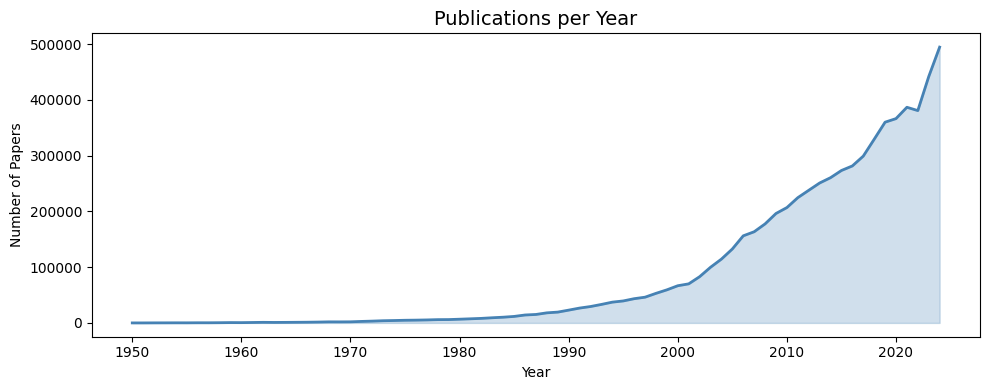

In [ ]:
df_year = con.sql(f"""
    SELECT year, COUNT(*) AS papers
    FROM papers
    WHERE year BETWEEN 1950 AND 2024
    GROUP BY year
    ORDER BY year
""").df()
 
fig, ax = plt.subplots(figsize=(10,4))
ax.fill_between(df_year["year"], df_year["papers"], alpha=0.25, color="steelblue")
ax.plot(df_year["year"], df_year["papers"], color="steelblue", linewidth=2)
ax.set_title("Publications per Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Papers")

plt.tight_layout()
plt.show()
 

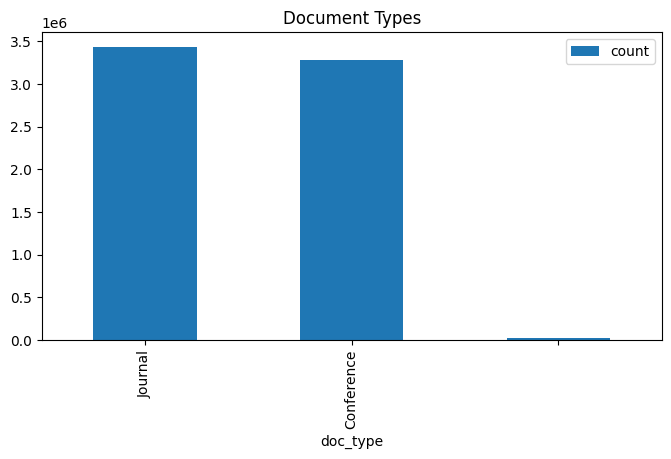

In [ ]:
df = con.sql(f"""
    SELECT doc_type, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE doc_type IS NOT NULL
    GROUP BY doc_type ORDER BY count DESC
""").df()

df.plot(kind="bar", x="doc_type", y="count", title="Document Types", figsize=(8,4))
plt.show()

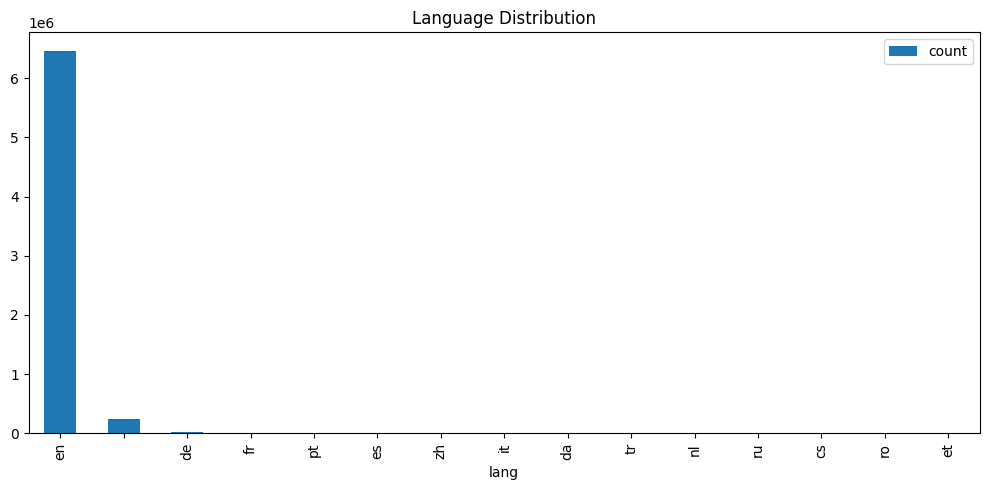

In [ ]:
# Language distribution from parquet
df = con.sql(f"""
    SELECT lang, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE lang IS NOT NULL
    GROUP BY lang 
    ORDER BY count DESC
    LIMIT 15
""").df()

df.plot(kind="bar", x="lang", y="count", title="Language Distribution", figsize=(10, 5))
plt.tight_layout()
plt.show()

## Citation Analysis

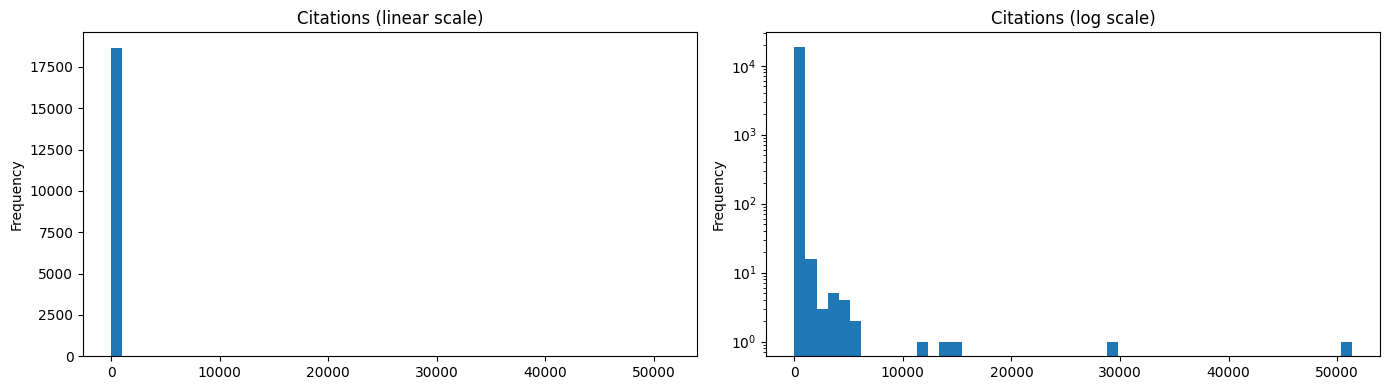

In [ ]:
df = con.sql(f"""
    SELECT n_citation
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE n_citation IS NOT NULL AND n_citation > 0
    USING SAMPLE 20000
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["n_citation"].plot(kind="hist", bins=50, ax=axes[0], title="Citations (linear scale)")
df["n_citation"].apply(lambda x: x+1).plot(kind="hist", bins=50, logy=True, ax=axes[1], title="Citations (log scale)")
plt.tight_layout()
plt.show()

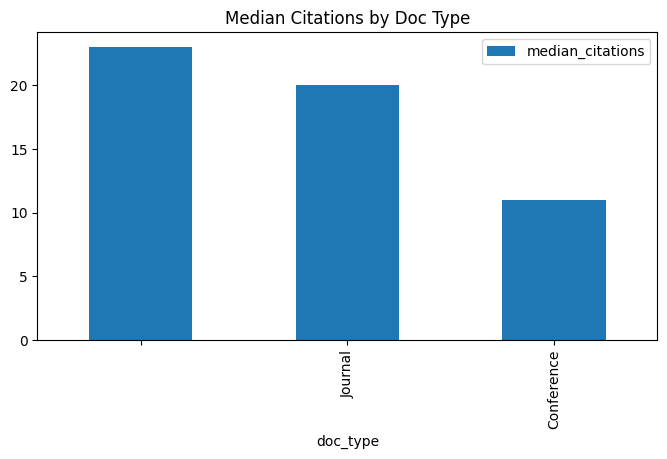

In [ ]:
df = con.sql(f"""
    SELECT doc_type,
           COUNT(*) AS papers,
           AVG(n_citation) AS avg_citations,
           MEDIAN(n_citation) AS median_citations
    
    -- FROM papers         
    FROM read_parquet('{PARQUET}')
    WHERE doc_type IS NOT NULL AND n_citation IS NOT NULL
    GROUP BY doc_type ORDER BY median_citations DESC
""").df()

df.plot(kind="bar", x="doc_type", y="median_citations", title="Median Citations by Doc Type", figsize=(8,4))
plt.show()

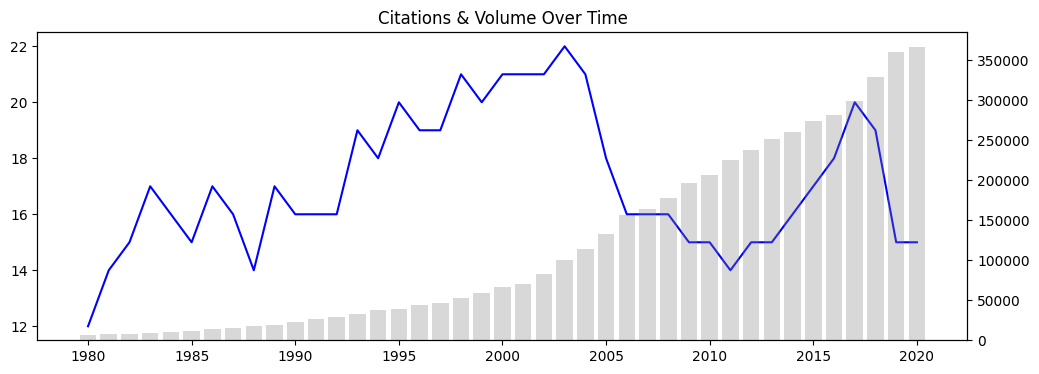

In [ ]:
df = con.sql(f"""
    SELECT year,
           MEDIAN(n_citation) AS median_citations,
           COUNT(*) AS papers
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE year BETWEEN 1980 AND 2020 AND n_citation IS NOT NULL
    GROUP BY year ORDER BY year
""").df()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(df["year"], df["median_citations"], color="blue", label="Median citations")
ax2.bar(df["year"], df["papers"], alpha=0.3, color="gray", label="Paper count")
ax1.set_title("Citations & Volume Over Time")
plt.show()

## Authors and Collaborations

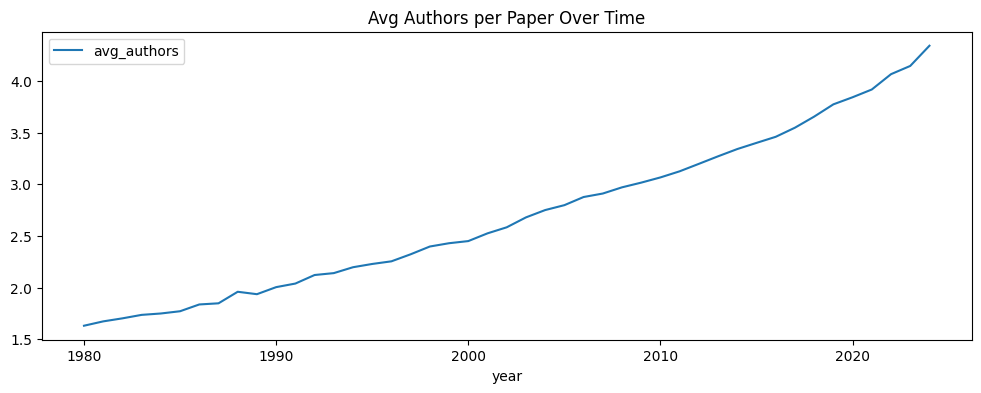

In [ ]:
df = con.sql(f"""
    SELECT year,
           AVG(ARRAY_LENGTH(authors)) AS avg_authors
 -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE year BETWEEN 1980 AND 2024 AND authors IS NOT NULL
    GROUP BY year ORDER BY year
""").df()

df.plot(kind="line", x="year", y="avg_authors", title="Avg Authors per Paper Over Time", figsize=(12,4))
plt.show()

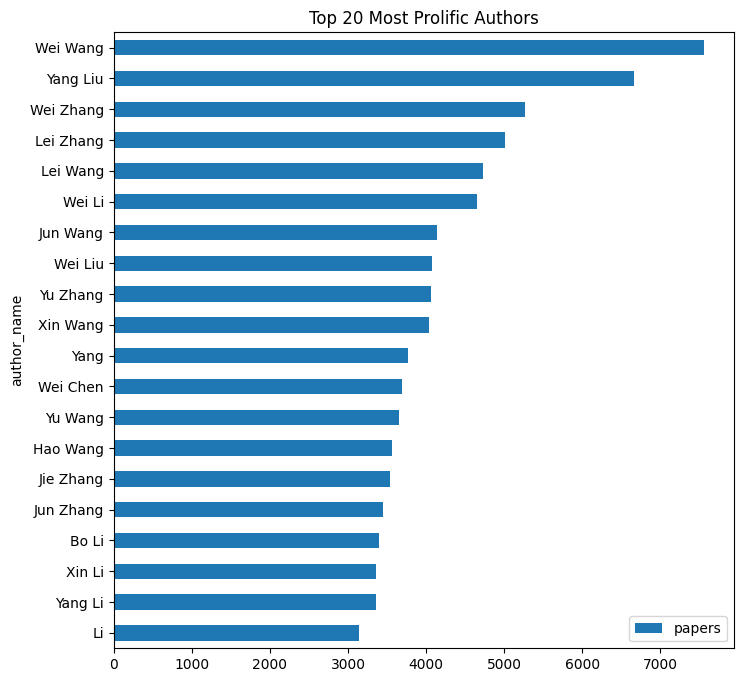

In [ ]:
df = con.sql(f"""
    SELECT
        author.name AS author_name,
        COUNT(*) AS papers
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.name IS NOT NULL
      AND author.name != ''
    GROUP BY 1
    ORDER BY papers DESC
    LIMIT 20
""").df()

df.plot(kind="barh", x="author_name", y="papers", title="Top 20 Most Prolific Authors", figsize=(8,8))
plt.gca().invert_yaxis()
plt.show()

## Keywords and Venues

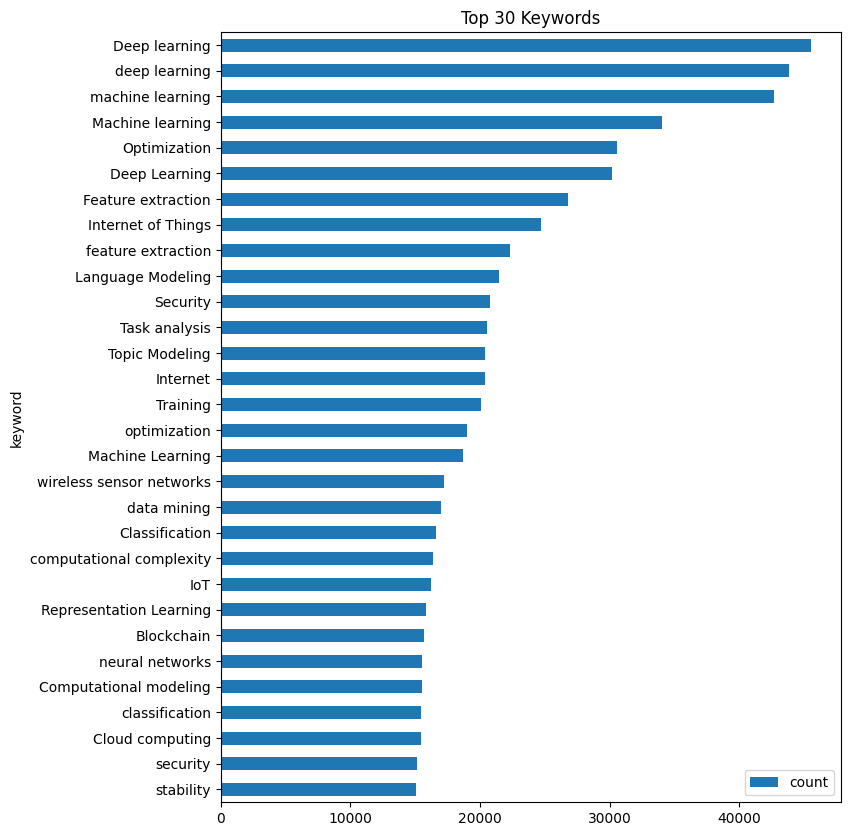

In [ ]:
df = con.sql(f"""
    SELECT kw AS keyword, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(keywords) AS t(kw)
    WHERE kw IS NOT NULL AND kw != ''
    GROUP BY kw
    ORDER BY count DESC
    LIMIT 30
""").df()

df.plot(kind="barh", x="keyword", y="count", title="Top 30 Keywords", figsize=(8,10))
plt.gca().invert_yaxis()
plt.show()

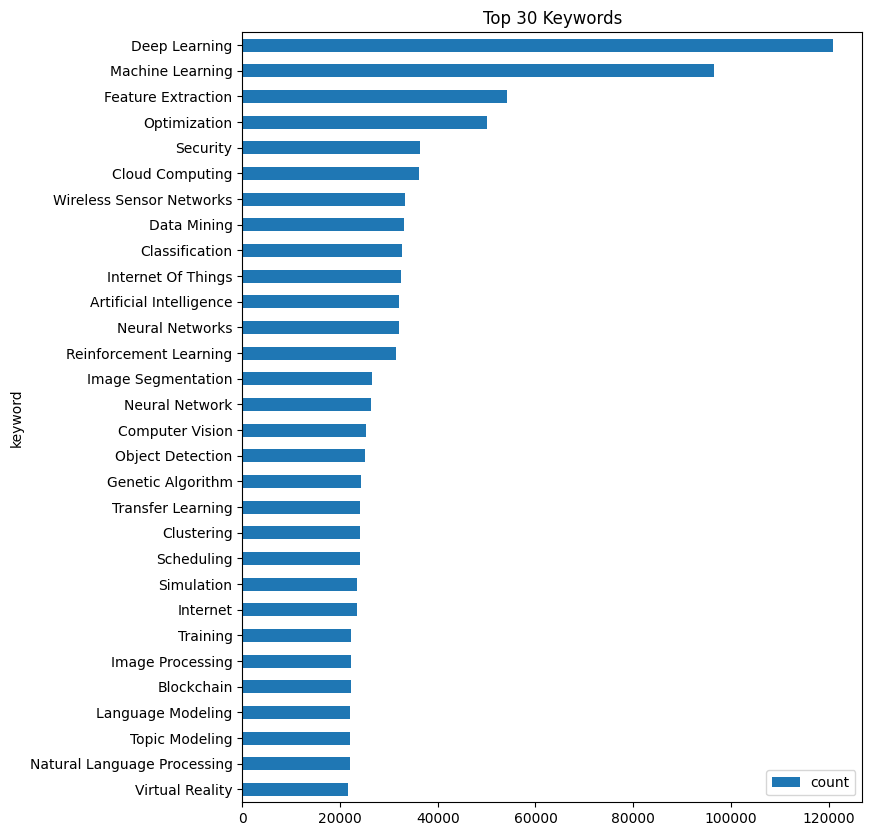

In [ ]:
# merge identical keywords by case

def to_camel_case(s):
    return ' '.join(word.capitalize() for word in s.split())

raw = con.sql(f"""
    SELECT kw AS keyword
    FROM read_parquet('{PARQUET}')
    -- FROM papers
    CROSS JOIN
         UNNEST(keywords) AS t(kw)
    WHERE kw IS NOT NULL AND kw != ''
""").df()

raw['keyword'] = raw['keyword'].apply(to_camel_case)

df = (
    raw.groupby('keyword', as_index=False)
       .size()
       .rename(columns={'size': 'count'})
       .sort_values('count', ascending=False)
       .head(30)
)

df.plot(kind="barh", x="keyword", y="count", title="Top 30 Keywords", figsize=(8, 10))
plt.gca().invert_yaxis()
plt.show()

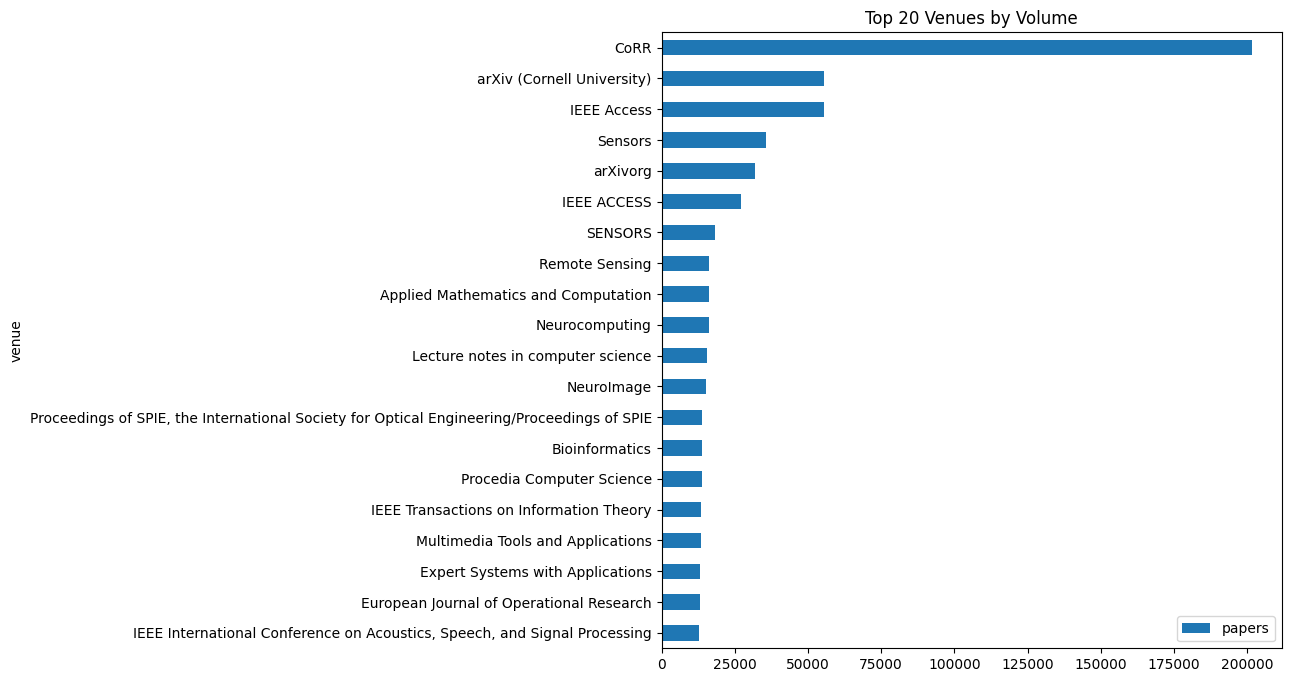

In [ ]:
df = con.sql(f"""
    SELECT venue, COUNT(*) AS papers, MEDIAN(n_citation) AS median_citations
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE venue IS NOT NULL AND venue != ''
    GROUP BY venue
    ORDER BY papers DESC
    LIMIT 20
""").df()

df.plot(kind="barh", x="venue", y="papers", title="Top 20 Venues by Volume", figsize=(8,8))
plt.gca().invert_yaxis()
plt.show()

##  Missingness

In [ ]:
# Missingness report (null + empty string/array) from parquet
missing_df = con.sql(f"""
WITH base AS (
    SELECT
        COUNT(*)::DOUBLE AS total_rows,
        SUM(CASE WHEN id IS NULL OR TRIM(COALESCE(id, '')) = '' THEN 1 ELSE 0 END) AS miss_id,
        SUM(CASE WHEN title IS NULL OR TRIM(COALESCE(title, '')) = '' THEN 1 ELSE 0 END) AS miss_title,
        SUM(CASE WHEN abstract IS NULL OR TRIM(COALESCE(abstract, '')) = '' THEN 1 ELSE 0 END) AS miss_abstract,
        SUM(CASE WHEN keywords IS NULL OR ARRAY_LENGTH(keywords) = 0 THEN 1 ELSE 0 END) AS miss_keywords,
        SUM(CASE WHEN year IS NULL THEN 1 ELSE 0 END) AS miss_year,
        SUM(CASE WHEN authors IS NULL OR ARRAY_LENGTH(authors) = 0 THEN 1 ELSE 0 END) AS miss_authors,
        SUM(CASE WHEN "references" IS NULL OR ARRAY_LENGTH("references") = 0 THEN 1 ELSE 0 END) AS miss_references,
        SUM(CASE WHEN lang IS NULL OR TRIM(COALESCE(lang, '')) = '' THEN 1 ELSE 0 END) AS miss_lang,
        SUM(CASE WHEN venue IS NULL OR TRIM(COALESCE(venue, '')) = '' THEN 1 ELSE 0 END) AS miss_venue,
        SUM(CASE WHEN doc_type IS NULL OR TRIM(COALESCE(doc_type, '')) = '' THEN 1 ELSE 0 END) AS miss_doc_type,
        SUM(CASE WHEN doi IS NULL OR TRIM(COALESCE(doi, '')) = '' THEN 1 ELSE 0 END) AS miss_doi,
        SUM(CASE WHEN page_start IS NULL OR TRIM(COALESCE(page_start, '')) = '' THEN 1 ELSE 0 END) AS miss_page_start,
        SUM(CASE WHEN page_end IS NULL OR TRIM(COALESCE(page_end, '')) = '' THEN 1 ELSE 0 END) AS miss_page_end,
        SUM(CASE WHEN n_citation IS NULL THEN 1 ELSE 0 END) AS miss_n_citation
    FROM read_parquet('{PARQUET}')
    -- FROM papers
)
SELECT * FROM (
    SELECT 'id' AS feature,        100.0 * miss_id / total_rows AS missing_pct FROM base
    UNION ALL SELECT 'title',      100.0 * miss_title / total_rows FROM base
    UNION ALL SELECT 'abstract',   100.0 * miss_abstract / total_rows FROM base
    UNION ALL SELECT 'keywords',   100.0 * miss_keywords / total_rows FROM base
    UNION ALL SELECT 'year',       100.0 * miss_year / total_rows FROM base
    UNION ALL SELECT 'authors',    100.0 * miss_authors / total_rows FROM base
    UNION ALL SELECT 'references', 100.0 * miss_references / total_rows FROM base
    UNION ALL SELECT 'lang',       100.0 * miss_lang / total_rows FROM base
    UNION ALL SELECT 'venue',      100.0 * miss_venue / total_rows FROM base
    UNION ALL SELECT 'doc_type',   100.0 * miss_doc_type / total_rows FROM base
    UNION ALL SELECT 'doi',        100.0 * miss_doi / total_rows FROM base
    UNION ALL SELECT 'page_start', 100.0 * miss_page_start / total_rows FROM base
    UNION ALL SELECT 'page_end',   100.0 * miss_page_end / total_rows FROM base
    UNION ALL SELECT 'n_citation', 100.0 * miss_n_citation / total_rows FROM base
)
ORDER BY missing_pct DESC
""").df()

display(missing_df)

,feature,missing_pct
0,page_end,27.977907
1,page_start,26.567752
2,keywords,16.196907
3,references,15.643282
4,doi,8.945102
5,abstract,5.377448
6,lang,3.604579
7,venue,0.667016
8,doc_type,0.312697
9,authors,0.000045


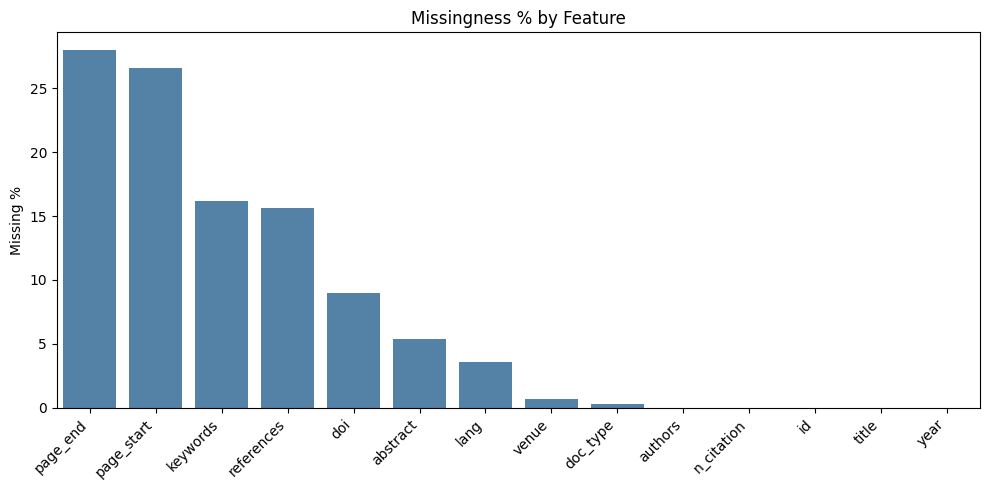

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x="feature", y="missing_pct", color="steelblue")
plt.title("Missingness % by Feature")
plt.ylabel("Missing %")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Data Quality

In [ ]:
df = con.sql(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(title) AS has_title,
        COUNT(abstract) AS has_abstract,
        COUNT(year) AS has_year,
        COUNT(doi) AS has_doi,
        COUNT(n_citation) AS has_citations,
        COUNT(venue) AS has_venue
    -- FROM papers
    FROM read_parquet('{PARQUET}')
""").df()

print(df.T)

                     0
total          6729828
has_title      6729828
has_abstract   6729828
has_year       6729828
has_doi        6729828
has_citations  6729828
has_venue      6703333


# Data quality

In [ ]:
df = con.sql(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(title) AS has_title,
        COUNT(abstract) AS has_abstract,
        COUNT(year) AS has_year,
        COUNT(doi) AS has_doi,
        COUNT(n_citation) AS has_citations,
        COUNT(venue) AS has_venue
    -- FROM papers
    FROM read_parquet('{PARQUET}')
""").df()

print(df.T)

                     0
total          6729828
has_title      6729828
has_abstract   6729828
has_year       6729828
has_doi        6729828
has_citations  6729828
has_venue      6703333


## What this next check does (author.id / author.org missingness)
It explodes the authors array so each author mention in each paper is one row.
Then it counts how often author.id is missing, how often author.org is missing, and how often both are missing.
Output is a table with counts and percentages.
How to read it:

- High miss_author_id_pct means many authors cannot be uniquely tracked across papers.
- High miss_author_org_pct means affiliation-based features may be weak/noisy.
- High miss_both_pct means severe metadata incompleteness for author-level modeling.

In [ ]:
# Missing author.id and author.org rates (explicit)
missing_author_fields_df = con.sql(f"""
WITH a AS (
    SELECT
        author.name AS author_name,
        author.id   AS author_id,
        author.org  AS author_org
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
),
base AS (
    SELECT
        COUNT(*)::DOUBLE AS total_author_mentions,
        SUM(CASE WHEN author_id IS NULL OR TRIM(COALESCE(author_id, '')) = '' THEN 1 ELSE 0 END) AS miss_author_id,
        SUM(CASE WHEN author_org IS NULL OR TRIM(COALESCE(author_org, '')) = '' THEN 1 ELSE 0 END) AS miss_author_org,
        SUM(CASE WHEN (author_id IS NULL OR TRIM(COALESCE(author_id, '')) = '')
                  AND (author_org IS NULL OR TRIM(COALESCE(author_org, '')) = '')
                 THEN 1 ELSE 0 END) AS miss_both
    FROM a
)
SELECT
    total_author_mentions,
    miss_author_id,
    ROUND(100.0 * miss_author_id / NULLIF(total_author_mentions, 0), 4) AS miss_author_id_pct,
    miss_author_org,
    ROUND(100.0 * miss_author_org / NULLIF(total_author_mentions, 0), 4) AS miss_author_org_pct,
    miss_both,
    ROUND(100.0 * miss_both / NULLIF(total_author_mentions, 0), 4) AS miss_both_pct
FROM base;
""").df()
display(missing_author_fields_df)

,total_author_mentions,miss_author_id,miss_author_id_pct,miss_author_org,miss_author_org_pct,miss_both,miss_both_pct
0,22998013.0,2284412.0,9.9331,4208990.0,18.3015,802063.0,3.4875


author.id missing ≈ 9.94% author.org missing ≈ 18.30% both missing ≈ 3.48%

Missingness is too high for author.org; dropping would bias data

We should create missingness features. booleans like: has_author_id, has_author_org, and pair-level both_have_org.

Use author.id as primary identity, normalized name only as fallback.

With this class rate, train on sampled negatives (e.g., 1:5 or 1:10 pos:neg) and evaluate with PR-AUC / Recall@K, not accuracy.

## What this next check does (author-name variation / normalization)
It normalizes names (lowercase, remove punctuation, collapse spaces).
It groups by normalized form and finds cases where many raw spellings map to the same normalized author string.
Output shows likely spelling/format variants (for example accents, dots, extra spaces, initials).
How to read it:

- n_raw_variants = number of distinct original spellings for the same normalized name.
- mentions = total occurrences of that normalized name.
- raw_variants lists the observed spellings with counts.
Important:

This is a heuristic quality check, not true entity resolution.
Same normalized name can still refer to different people (homonyms).

In [ ]:
# 2) Author-name variation / normalization checks (memory-safe)

# DuckDB tuning for this heavy aggregation
con.sql("SET preserve_insertion_order = false;")
con.sql("SET threads = 4;")

name_variation_df = con.sql(f"""
WITH flat AS (
    SELECT TRIM(author.name) AS raw_name
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.name IS NOT NULL AND TRIM(author.name) <> ''
),
norm_counts AS (
    SELECT
        LOWER(
            REGEXP_REPLACE(
                REGEXP_REPLACE(raw_name, '[^[:alnum:] ]', ' ', 'g'),
                '\\s+', ' ', 'g'
            )
        ) AS normalized_name,
        raw_name,
        COUNT(*) AS raw_mentions
    FROM flat
    GROUP BY 1, 2
),
name_stats AS (
    SELECT
        normalized_name,
        SUM(raw_mentions) AS mentions,
        COUNT(*) AS n_raw_variants
    FROM norm_counts
    GROUP BY normalized_name
    HAVING COUNT(*) > 1
    ORDER BY n_raw_variants DESC, mentions DESC
    LIMIT 30
)
SELECT
    s.normalized_name,
    s.mentions,
    s.n_raw_variants,
    STRING_AGG(
        nc.raw_name || ' (' || CAST(nc.raw_mentions AS VARCHAR) || ')',
        ' | '
        ORDER BY nc.raw_mentions DESC, nc.raw_name
    ) AS raw_variants
FROM name_stats s
JOIN norm_counts nc USING (normalized_name)
GROUP BY s.normalized_name, s.mentions, s.n_raw_variants
ORDER BY s.n_raw_variants DESC, s.mentions DESC;
""").df()

display(name_variation_df)

,normalized_name,mentions,n_raw_variants,raw_variants
0,,2018.0,1909,刘炜 (5) | 王作英 (4) | : (3) | 于炯 (3) | 刘伟 (3) | 刘...
1,c c jay kuo,605.0,14,C. -C. Jay Kuo (372) | C.-C. Jay Kuo (107) | C...
2,yang liu,6701.0,10,Yang Liu (6662) | Yang Liu (14) | Yang Liu (1...
3,xuemin sherman shen,901.0,10,Xuemin (Sherman) Shen (815) | Xuemin Sherman S...
4,wil m p van der aalst,645.0,10,Wil M. P. van der Aalst (598) | Wil M. P. Van ...
5,alex sandy pentland,98.0,10,Alex 'Sandy' Pentland (35) | Alex (Sandy) Pent...
6,max q h meng,491.0,9,Max Q. -H. Meng (251) | Max Q-H Meng (107) | M...
7,florian floyd mueller,202.0,9,Florian 'Floyd' Mueller (167) | Florian Floyd ...
8,willem jan van den heuvel,153.0,9,Willem-Jan van den Heuvel (115) | Willem-Jan V...
9,y h taguchi,37.0,9,Y-h. Taguchi (16) | Y-h Taguchi (8) | Y-H. Tag...


The name-variation table is for finding likely spelling variants; treat it as cleaning support, not truth.

We should build canonical text forms (lowercase, trim, punctuation/space cleanup, unicode normalization). Keep a small manual alias map for top recurring variants from the variation output

## What this next check does (temporal consistency of affiliations)
- It keeps authors with a valid author.id and year.
- For each author across time, it counts how many distinct non-empty organizations appear.
- It returns authors with more than one organization over their timeline.

How to read it:

- n_distinct_orgs > 1 can mean real career moves or inconsistent/dirty org strings.
- timeline_rows and year range (first_year, last_year) give context on how broad the timeline is.
- Rows at the top are the strongest candidates for manual cleaning rules (org normalization, alias mapping).

In [ ]:
# Temporal consistency of author affiliations
author_org_temporal_df = con.sql(f"""
WITH author_timeline AS (
    SELECT
        author.id AS author_id,
        MIN(TRIM(author.name)) AS sample_name,
        year,
        NULLIF(TRIM(author.org), '') AS org
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.id IS NOT NULL AND TRIM(author.id) <> ''
      AND year IS NOT NULL
    GROUP BY author.id, year, NULLIF(TRIM(author.org), '')
)
 ,agg AS (
    SELECT
        author_id,
        MIN(sample_name) AS sample_name,
        COUNT(*) AS timeline_rows,
        COUNT(DISTINCT org) FILTER (WHERE org IS NOT NULL) AS n_distinct_orgs,
        MIN(year) AS first_year,
        MAX(year) AS last_year
    FROM author_timeline
    GROUP BY author_id
)
SELECT
    author_id,
    sample_name,
    timeline_rows,
    n_distinct_orgs,
    first_year,
    last_year
FROM agg
WHERE n_distinct_orgs > 1
ORDER BY n_distinct_orgs DESC, timeline_rows DESC
LIMIT 30;
""").df()

display(author_org_temporal_df)

,author_id,sample_name,timeline_rows,n_distinct_orgs,first_year,last_year
0,53f6615fdabfae8dcd35b276,JIAO Li-cheng,929,599,1998,2025
1,542c458bdabfae2b4e1fb0c8,H Jin,903,537,1997,2025
2,53f48c1fdabfaea7cd1ce3f8,D. Tao,744,511,2004,2025
3,53f445bcdabfaee4dc7ce5dc,Alouini Mohamed-Slim,880,496,1997,2025
4,53f48ce5dabfaea7cd1d0893,Li Xuelong,659,441,1994,2025
5,5625051945cedb339856ec92,A Abraham,609,406,1998,2025
6,5429fd93dabfae61d494cf5d,G Wen,759,404,1990,2025
7,53f7ffb0dabfae90ec136659,N NAVAB,644,373,1989,2025
8,53f45044dabfaedf435f34cb,Benini Luca,741,371,1994,2025
9,54084ac2dabfae450f408e17,A Alimi,474,363,1993,2025


for example, the first row shows that:

The same author ID appears a lot in the dataset (786 author-year-org records). Across those records, there are 510 different organization strings. This is far too high to be realistic as true job changes, so it mostly indicates: noisy/inconsistent author.org text, variants of the same institution, possible mixed identities in the source.

What to do with it:

Keep author.id as the stable identity key. Normalize author.org (case, punctuation, spacing, abbreviations). Build an org alias map for top repeated variants. For modeling, use robust org features (has_org, normalized org match) rather than raw org string equality.

# Data Cleaning

In [ ]:
import re
import unicodedata

def normalize_text(value):
    if value is None:
        return ""
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

try:
    con.create_function("normalize_text", normalize_text, [str], str)
except Exception:
    pass

Author canonicalization layer: 'author.id' is the primary key, and normalized name is the fallback.

In [ ]:
con.sql(f"""
CREATE OR REPLACE TABLE author_mentions_clean AS
SELECT
    p.id AS paper_id,
    p.year,
    CASE
        WHEN a.author.id IS NOT NULL AND TRIM(a.author.id) <> ''
            THEN TRIM(a.author.id)
        ELSE 'name:' || normalize_text(a.author.name)
    END AS author_key,
    TRIM(a.author.id) AS author_id_raw,
    normalize_text(a.author.name) AS author_name_norm,
    TRIM(a.author.name) AS author_name_raw,
    normalize_text(a.author.org) AS author_org_norm
FROM read_parquet('{PARQUET}') p
-- FROM papers p
CROSS JOIN UNNEST(p.authors) AS a(author)
WHERE a.author.name IS NOT NULL
  AND TRIM(a.author.name) <> '';
""")

In [ ]:
con.sql("""
CREATE OR REPLACE TABLE author_name_canonical AS
WITH counts AS (
    SELECT
        author_key,
        author_name_norm,
        author_name_raw,
        COUNT(*) AS n_mentions
    FROM author_mentions_clean
    GROUP BY 1, 2, 3
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY author_key
            ORDER BY n_mentions DESC, LENGTH(author_name_raw) DESC, author_name_raw
        ) AS rn
    FROM counts
)
SELECT
    author_key,
    author_name_raw AS canonical_author_name,
    author_name_norm AS canonical_author_name_norm,
    n_mentions
FROM ranked
WHERE rn = 1;
""")

In [ ]:
display(con.sql("SELECT * FROM author_name_canonical LIMIT 10").df())

,author_key,canonical_author_name,canonical_author_name_norm,n_mentions
0,name:weixiao meng,Weixiao Meng,weixiao meng,1
1,name:weixin zhao,Weixin Zhao,weixin zhao,3
2,name:weixing zeng,Weixing Zeng,weixing zeng,1
3,name:weixing zhao,Weixing Zhao,weixing zhao,1
4,name:weiyun wang weiyun,Weiyun Wang Weiyun,weiyun wang weiyun,1
5,name:welile nxumalo,Welile Nxumalo,welile nxumalo,1
6,name:welzl,Welzl,welzl,1
7,name:wen chin wu,Wen-Chin Wu,wen chin wu,1
8,name:wen hsin chen,Wen-Hsin Chen,wen hsin chen,2
9,name:wen sheng li,Wen Sheng Li,wen sheng li,1


Use the resolved author-table cells below. The old raw-name join should not be used.

In [ ]:
con.sql("""
CREATE OR REPLACE TABLE paper_authors AS
SELECT
    am.paper_id AS id,
    am.author_key,
    ac.canonical_author_name AS author_name,
    am.author_org_norm
FROM author_mentions_clean am
LEFT JOIN author_name_canonical ac
    ON am.author_key = ac.author_key;
""")

con.sql("""
CREATE OR REPLACE TABLE author_stats AS
SELECT
    author_key,
    author_name,
    COUNT(*) AS author_papers,
    MEDIAN(p.n_citation) AS author_median_citations,
    AVG(p.n_citation) AS author_avg_citations,
    MAX(p.n_citation) AS author_max_citations
FROM paper_authors pa
JOIN papers p
    ON pa.id = p.id
GROUP BY author_key, author_name;
""")

con.sql(f"""
CREATE OR REPLACE TABLE features_author AS
SELECT
    p.id,
    COUNT(DISTINCT pa.author_key) AS n_authors,
    COALESCE(AVG(a.author_avg_citations), 0) AS avg_author_citations,
    COALESCE(MAX(a.author_max_citations), 0) AS max_author_citations,
    CASE WHEN COUNT(DISTINCT pa.author_key) > 1 THEN 1 ELSE 0 END AS multi_authored
FROM read_parquet('{PARQUET}') p
-- FROM papers p
LEFT JOIN paper_authors pa
    ON p.id = pa.id
LEFT JOIN author_stats a
    ON pa.author_key = a.author_key
GROUP BY p.id;
""")

display(con.sql("SELECT * FROM paper_authors LIMIT 10").df())

,id,author_key,author_name,author_org_norm
0,5a260c5217c44a4ba8a28595,542acc0adabfae646d588bcc,Dun Liu,southwest jiaotong univ sch econ management ch...
1,5a260c5217c44a4ba8a28d26,53f437c2dabfaedd74dad1ca,Adriana Gogonel,inria f 75589 le chesnay france
2,5a260c5217c44a4ba8a28e43,62e8b61dd9f20422f0c07425,Yanjun Shi,center for advanced power systems florida stat...
3,5a260c5717c44a4ba8a28fe2,65f3c539a43d7c2496b9da2d,Farzaneh Moradkhani,acecr ind intelligence res grp zanjan branch t...
4,5a260c5d17c44a4ba8a29ca6,53f35e1fdabfae4b3497a5b6,Chuangxin He,key laboratory of the education ministry for p...
5,5a260c5d17c44a4ba8a2a5ad,53f45da7dabfaee2a1d8e7dc,Mohammed W. Baidas,kuwait univ coll engn petr elect engn dept kuw...
6,5a260c6117c44a4ba8a2a80a,53f4515fdabfaeecd69d8401,Yogi A. Erlangga,nazarbayev univ dept math 53 kabanbay batyr av...
7,5a260c6117c44a4ba8a2a95a,53f430dddabfaedce54f1a3b,Zhi Quan,shenzhen univ coll informat engn shenzhen 5180...
8,5a260c6117c44a4ba8a2adf2,53f42eb2dabfaee4dc72a66c,M. Petzold,fraunhofer inst microstruct mat syst imws hall...
9,5a260c6117c44a4ba8a2b16a,62e4a4f1d9f204418d6cd93a,"Almubarak, Yara",humanoid biorobotics and smart systems hbs lab...


In [ ]:
con.sql(f"""
CREATE OR REPLACE TABLE papers_clean AS
WITH base AS (
    SELECT
        p.*,
        normalize_text(p.title) AS title_norm,
        normalize_text(p.abstract) AS abstract_norm,
        normalize_text(p.venue) AS venue_norm,
        normalize_text(p.doc_type) AS doc_type_norm,
        CASE
            WHEN p.id IS NULL OR TRIM(p.id) = '' THEN
                'paper_' || md5(
                    COALESCE(p.title, '') || '|' ||
                    COALESCE(p.abstract, '') || '|' ||
                    COALESCE(CAST(p.year AS VARCHAR), '') || '|' ||
                    COALESCE(p.venue, '')
                )
            ELSE TRIM(p.id)
        END AS id_clean,
        CASE WHEN p.id IS NULL OR TRIM(p.id) = '' THEN 1 ELSE 0 END AS was_missing_id
    -- FROM papers p
    FROM read_parquet('{PARQUET}') p
)
SELECT
    id_clean AS id,
    NULLIF(title_norm, '') AS title,
    NULLIF(abstract_norm, '') AS abstract,
    year,
    authors,
    keywords,
    "references",
    NULLIF(venue_norm, '') AS venue,
    CASE
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(conference|symposium|workshop|proceedings|meeting)') THEN 'conference'
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(journal|transactions|letters)') THEN 'journal'
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(book|chapter|lecture notes)') THEN 'book'
        WHEN doc_type_norm IN ('article', 'journal article') THEN 'journal'
        WHEN doc_type_norm IN ('inproceedings', 'conference paper', 'conference') THEN 'conference'
        WHEN doc_type_norm = '' THEN 'unknown'
        ELSE doc_type_norm
    END AS doc_type,
    doi,
    page_start,
    page_end,
    n_citation,
    ARRAY_LENGTH(authors) AS n_authors,
    ARRAY_LENGTH(keywords) AS n_keywords,
    ARRAY_LENGTH("references") AS n_references,
    LENGTH(COALESCE(NULLIF(title_norm, ''), '')) AS title_len,
    LENGTH(COALESCE(NULLIF(abstract_norm, ''), '')) AS abstract_len,
    TRY_CAST(page_end AS BIGINT) - TRY_CAST(page_start AS BIGINT) AS page_count,
    was_missing_id
FROM base;
""")

con.sql("CREATE OR REPLACE TABLE papers AS SELECT * FROM papers_clean")

display(con.sql("SELECT id, title, venue, doc_type, was_missing_id FROM papers LIMIT 5").df())

,id,title,venue,doc_type,was_missing_id
0,53e99a2bb7602d970228506a,detecting syn flooding attacks,ieee infocom 2002 the conference on computer c...,conference,0
1,53e99a35b7602d9702296316,computing the constrained m estimates for regr...,computational statistics data analysis,journal,0
2,53e99a3cb7602d97022981c5,receiver operating characteristic analysis of ...,ieee transactions on systems man and cybernetics,journal,0
3,53e99a43b7602d97022a537d,a creative renewal programme,ai society,journal,0
4,53e99a43b7602d97022a578f,asymptotic continuous petri nets,discrete event dynamic systems,journal,0


# Target Focused Exploration

In [ ]:
# Class balance: citation links (positive) vs non-links (negative)

# Assumptions:
## - `papers.id` is the paper identifier
## - `papers.references` is an array of cited paper ids
## - we only keep references that point to ids present in `papers`

# Set temp directory for DuckDB (Windows fix)

balance_df = con.sql(f"""
WITH ids AS (
    SELECT DISTINCT id
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE id IS NOT NULL AND TRIM(id) <> ''
)
 ,pos AS (
    SELECT DISTINCT
        p.id AS src_id,
        ref AS dst_id
    -- FROM papers p
    FROM read_parquet('{PARQUET}') p
    CROSS JOIN UNNEST(p."references") AS t(ref)
    INNER JOIN ids i ON i.id = ref
    WHERE p.id IS NOT NULL
      AND TRIM(p.id) <> ''
      AND ref IS NOT NULL
      AND TRIM(ref) <> ''
      AND p.id <> ref
)
 ,counts AS (
    SELECT
        (SELECT COUNT(*) FROM ids) AS n_nodes,
        (SELECT COUNT(*) FROM pos) AS n_positive_links
)
SELECT
    n_nodes,
    n_positive_links,
    (n_nodes * (n_nodes - 1) - n_positive_links) AS n_non_links,
    ROUND(100.0 * n_positive_links / NULLIF(n_nodes * (n_nodes - 1), 0), 6) AS positive_rate_pct,
    ROUND(100.0 * (n_nodes * (n_nodes - 1) - n_positive_links) / NULLIF(n_nodes * (n_nodes - 1), 0), 6) AS non_link_rate_pct
FROM counts;
""").df()

display(balance_df)

,n_nodes,n_positive_links,n_non_links,positive_rate_pct,non_link_rate_pct
0,6729828,73640521,45290504539235,0.000163,99.999837


In [ ]:
# ratio as "1 positive : X negatives"
pos = float(balance_df.loc[0, "n_positive_links"])
neg = float(balance_df.loc[0, "n_non_links"])
print(f"Positive link rate: {balance_df.loc[0, 'positive_rate_pct']:.6f}%")
print(f"Non-link rate: {balance_df.loc[0, 'non_link_rate_pct']:.6f}%")

Positive link rate: 0.000163%
Non-link rate: 99.999837%


# Pair Level Analysis

## Features selection

### Correlation Matrix

In [ ]:
# df = con.sql(f"""
#     SELECT
#         ARRAY_LENGTH(authors) AS n_authors,
#         ARRAY_LENGTH(keywords) AS n_keywords,
#         ARRAY_LENGTH("references") AS n_references,
#         TRY_CAST(page_end AS INT) - TRY_CAST(page_start AS INT) AS page_count,
#         LENGTH(abstract) AS abstract_length,
#         n_citation
#     FROM read_parquet('{PARQUET}')
#     WHERE n_citation IS NOT NULL
#     USING SAMPLE 20000
# """).df().dropna()

# sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Feature Correlations")
# plt.tight_layout()
# plt.show()

There are no correlated features in the original dataset, only a little correlation between n_references and abstract_lenght.

# Feature Selection

### 1 TEXT-BASED FEATURES

Features da **titolo** e **abstract** per catturare complessità e specificità:
- `title_word_count` → Lunghezza titolo
- `abstract_word_count` → Lunghezza abstract  
- `title_complexity` → Media parole nel titolo (linguaggio tecnico)
- `abstract_complexity` → Media parole nell'abstract
- `has_numbers_*` → Presenza numeri (specificità)

In [ ]:
text_sql = """
CREATE OR REPLACE TABLE features_text AS
SELECT 
    id,
    CASE WHEN title IS NULL THEN 0 
         ELSE ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' '))
    END AS title_word_count,
    
    CASE WHEN abstract IS NULL THEN 0 
         ELSE ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' '))
    END AS abstract_word_count,
    
    CASE WHEN LENGTH(COALESCE(abstract, '')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(title, '')) AS FLOAT) / LENGTH(COALESCE(abstract, ''))
    END AS title_abstract_ratio,
    
    CASE WHEN title IS NULL OR ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' ')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(title, '')) AS FLOAT) / ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' '))
    END AS title_complexity,
    
    CASE WHEN abstract IS NULL OR ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' ')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(abstract, '')) AS FLOAT) / ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' '))
    END AS abstract_complexity,
    
    CASE WHEN title ~ '[0-9]' THEN 1 ELSE 0 END AS has_numbers_in_title,
    CASE WHEN abstract ~ '[0-9]' THEN 1 ELSE 0 END AS has_numbers_in_abstract
    
FROM read_parquet('{PARQUET}')
""".format(PARQUET=PARQUET)

con.sql(text_sql)
print("DONE")

DONE


### 2️ AUTHOR-BASED FEATURES

Features che catturano **reputazione** e **collaborazione**:
- `n_authors` → Numero autori  
- `first_author_avg_citations` → Media cit. primo autore (star lead researcher)
- `avg_author_citations` → Media cit. aggregato autori
- `max_author_citations` → Max cit. tra autori (presenza di star)
- `multi_authored` → Flag collaborazione (>1 autore)

In [ ]:
# Compute author statistics
author_stats_sql = """
CREATE OR REPLACE TABLE author_stats AS
SELECT 
    author.name AS author_name,
    COUNT(*) AS author_papers,
    MEDIAN(n_citation) AS author_median_citations,
    AVG(n_citation) AS author_avg_citations,
    MAX(n_citation) AS author_max_citations
FROM read_parquet('{PARQUET}') 
CROSS JOIN UNNEST(authors) AS t(author)
WHERE author.name IS NOT NULL AND author.name != ''
GROUP BY author.name
""".format(PARQUET=PARQUET)

con.sql(author_stats_sql)
print("Author statistics DONE")

# Create paper-author links
paper_author_sql = """
CREATE OR REPLACE TABLE paper_authors AS
SELECT 
    p.id,
    author.name AS author_name
FROM read_parquet('{PARQUET}') AS p
CROSS JOIN UNNEST(p.authors) AS t(author)
WHERE author.name IS NOT NULL AND author.name != ''
""".format(PARQUET=PARQUET)

con.sql(paper_author_sql)
print("Paper-author links DONE")

# Join with author stats
author_features_sql = """
CREATE OR REPLACE TABLE features_author AS
SELECT 
    p.id,
    ARRAY_LENGTH(p.authors) AS n_authors,
    
    COALESCE(AVG(a.author_avg_citations), 0) AS avg_author_citations,
    COALESCE(MAX(a.author_max_citations), 0) AS max_author_citations,
    
    CASE WHEN ARRAY_LENGTH(p.authors) > 1 THEN 1 ELSE 0 END AS multi_authored

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN paper_authors pa ON p.id = pa.id
LEFT JOIN author_stats a ON pa.author_name = a.author_name
GROUP BY p.id, ARRAY_LENGTH(p.authors)
""".format(PARQUET=PARQUET)

con.sql(author_features_sql)
print("AUTHOR-BASED FEATURES DONE")

Author statistics DONE
Paper-author links DONE
AUTHOR-BASED FEATURES DONE


### 3 NETWORK & REFERENCE FEATURES

- `n_references` → Numero di riferimenti citati  
- `references_author_ratio` → Riferimenti per autore
- `citation_richness` → Densità riferimenti rispetto abstract
- `has_high_ref_count` → Flag papers che sono review/comprehensive (>50 ref)

In [ ]:
network_sql = """
CREATE OR REPLACE TABLE features_network AS
SELECT 
    id,
    ARRAY_LENGTH("references") AS n_references,
    
    CASE WHEN ARRAY_LENGTH(authors) = 0 THEN 0
         ELSE CAST(ARRAY_LENGTH("references") AS FLOAT) / ARRAY_LENGTH(authors)
    END AS references_author_ratio,
    
    CASE WHEN LENGTH(abstract) = 0 THEN 0
         ELSE CAST(ARRAY_LENGTH("references") AS FLOAT) / (LENGTH(abstract) / 100.0)
    END AS citation_richness,
    
    CASE WHEN ARRAY_LENGTH("references") > 50 THEN 1 ELSE 0 END AS has_high_ref_count

FROM read_parquet('{PARQUET}')
""".format(PARQUET=PARQUET)

con.sql(network_sql)
print("NETWORK & REFERENCE FEATURES DONE")

NETWORK & REFERENCE FEATURES DONE


### 4 TEMPORAL FEATURES

Features che catturano **recency** e **stagionalità**:
- `years_since_publication` → Anni dalla pubblicazione (non usare lineare!)
- `publication_era` → Era storica (pre-2000, 2000-2009, 2010-2019, 2020+)
- `decade` → Decennio della pubblicazione
- `is_recent` → Flag se pubblicato negli ultimi 5 anni

In [ ]:
temporal_sql = """
CREATE OR REPLACE TABLE features_temporal AS
SELECT 
    id,
    year,
    (2024 - year) AS years_since_publication,
    
    CASE 
        WHEN year < 2000 THEN 'pre-2000'
        WHEN year < 2010 THEN '2000-2009'
        WHEN year < 2020 THEN '2010-2019'
        ELSE '2020+'
    END AS publication_era,
    
    CAST(year / 10 * 10 AS INT) AS decade,
    
    CASE WHEN year >= 2019 THEN 1 ELSE 0 END AS is_recent

FROM read_parquet('{PARQUET}')
WHERE year IS NOT NULL
""".format(PARQUET=PARQUET)

con.sql(temporal_sql)
print("TEMPORAL FEATURES DONE")

TEMPORAL FEATURES DONE


### 5 QUALITY & IMPACT FEATURES

Features che rappresentano **qualità e impatto** normalizzati nel tempo:
- `citation_per_year` → Velocità accumulo citazioni (normalizzato per recency)  
- `is_highly_cited_for_year` → Flag se sopra mediana dell'anno
- `impact_score` → Composito: (cit/years × ln(peers per year)) **BEST predictor**

In [ ]:
# Compute year statistics for normalization
con.sql("""
CREATE OR REPLACE TABLE year_citation_stats AS
SELECT 
    year,
    MEDIAN(n_citation) AS median_citations_per_year,
    AVG(n_citation) AS avg_citations_per_year,
    COUNT(*) AS papers_per_year
FROM read_parquet('{PARQUET}')
WHERE year IS NOT NULL AND n_citation IS NOT NULL
GROUP BY year
""".format(PARQUET=PARQUET))

quality_sql = """
CREATE OR REPLACE TABLE features_quality AS
SELECT 
    p.id,
    p.year,
    p.n_citation,
    
    CASE 
        WHEN (2024 - p.year) = 0 THEN CAST(p.n_citation AS FLOAT)
        WHEN p.n_citation = 0 THEN 0.0
        ELSE CAST(p.n_citation AS FLOAT) / CAST((2024 - p.year) AS FLOAT)
    END AS citation_per_year,
    
    CASE 
        WHEN p.n_citation >= COALESCE(ycs.median_citations_per_year, 0) THEN 1 
        ELSE 0 
    END AS is_highly_cited_for_year,
    
    (CAST(p.n_citation AS FLOAT) / CAST((2024 - p.year + 1) AS FLOAT)) * 
    (1 + LN(CAST(COALESCE(ycs.papers_per_year, 1) AS FLOAT))) AS impact_score
    
FROM read_parquet('{PARQUET}') AS p
LEFT JOIN year_citation_stats AS ycs ON p.year = ycs.year
WHERE p.n_citation IS NOT NULL
""".format(PARQUET=PARQUET)

con.sql(quality_sql)
print("QUALITY & IMPACT FEATURES DONE")

QUALITY & IMPACT FEATURES DONE


### 6 VENUE & DOMAIN FEATURES

Features che catturano **prestigio del venue** e **accessibility**:
- `venue_median_citations` → Prestigi proxy del venue (STRONGEST PREDICTOR)
- `venue_volume` → Numero papers nel venue (importance marker)
- `is_top_venue` → Flag se venue è nei top 50
- `is_english` → Flag lingua inglese (global reach)
- `venue_tier` → Ordinale categorico (elite → high → medium → low)

In [ ]:
# Compute venue statistics
venue_stats_sql = """
CREATE OR REPLACE TABLE venue_stats AS
SELECT 
    venue,
    COUNT(*) AS venue_papers,
    MEDIAN(n_citation) AS venue_median_citations,
    AVG(n_citation) AS venue_avg_citations
FROM read_parquet('{PARQUET}')
WHERE venue IS NOT NULL AND venue != '' AND n_citation IS NOT NULL
GROUP BY venue
""".format(PARQUET=PARQUET)

con.sql(venue_stats_sql)

# Get top 50 venues
con.sql("CREATE OR REPLACE TABLE top_venues AS SELECT venue FROM venue_stats ORDER BY venue_median_citations DESC LIMIT 50")

# Create venue features
venue_features_sql = """
CREATE OR REPLACE TABLE features_venue AS
SELECT 
    p.id,
    p.venue,
    p.lang,
    
    COALESCE(vs.venue_median_citations, 0) AS venue_median_citations,
    COALESCE(vs.venue_papers, 0) AS venue_volume,
    
    CASE WHEN p.venue IN (SELECT venue FROM top_venues) THEN 1 ELSE 0 END AS is_top_venue,
    
    CASE WHEN UPPER(p.lang) IN ('EN', 'ENGLISH') THEN 1 ELSE 0 END AS is_english,
    
    CASE 
        WHEN COALESCE(vs.venue_median_citations, 0) > 100 THEN 'elite'
        WHEN COALESCE(vs.venue_median_citations, 0) > 50 THEN 'high'
        WHEN COALESCE(vs.venue_median_citations, 0) > 10 THEN 'medium'
        ELSE 'low'
    END AS venue_tier

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN venue_stats AS vs ON p.venue = vs.venue
""".format(PARQUET=PARQUET)

con.sql(venue_features_sql)
print("VENUE & DOMAIN FEATURES DONE")

VENUE & DOMAIN FEATURES DONE


###  CONSOLIDATE: Master Features Table

In [ ]:
master_sql = """
CREATE OR REPLACE TABLE papers_with_features AS
SELECT 
    p.id,
    p.title,
    p.year,
    p.n_citation AS target_variable,
    
    -- Text features
    ft.title_word_count,
    ft.abstract_word_count,
    ft.title_abstract_ratio,
    ft.title_complexity,
    ft.abstract_complexity,
    ft.has_numbers_in_title,
    ft.has_numbers_in_abstract,
    
    -- Author features
    fa.n_authors,
    fa.avg_author_citations,
    fa.max_author_citations,
    fa.multi_authored,
    
    -- Network features
    fn.n_references,
    fn.references_author_ratio,
    fn.citation_richness,
    fn.has_high_ref_count,
    
    -- Temporal features
    ft2.years_since_publication,
    ft2.publication_era,
    ft2.decade,
    ft2.is_recent,
    
    -- Quality features
    fq.citation_per_year,
    fq.is_highly_cited_for_year,
    fq.impact_score,
    
    -- Venue features
    fv.venue,
    fv.venue_median_citations,
    fv.venue_volume,
    fv.is_top_venue,
    fv.is_english,
    fv.venue_tier

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN features_text ft ON p.id = ft.id
LEFT JOIN features_author fa ON p.id = fa.id
LEFT JOIN features_network fn ON p.id = fn.id
LEFT JOIN features_temporal ft2 ON p.id = ft2.id
LEFT JOIN features_quality fq ON p.id = fq.id
LEFT JOIN features_venue fv ON p.id = fv.id

WHERE p.n_citation IS NOT NULL
""".format(PARQUET=PARQUET)

con.sql(master_sql)

# Check how many features we created
row_count = con.sql("SELECT COUNT(*) FROM papers_with_features").df().iloc[0, 0]
col_count = len(con.sql("SELECT * FROM papers_with_features LIMIT 1").df().columns)

print(f"\n DONE MASTER FEATURES TABLE CREATED!")
print(f"   • Rows: {row_count:,} papers")
print(f"   • Columns: {col_count} features + metadata")


 DONE MASTER FEATURES TABLE CREATED!
   • Rows: 6,729,828 papers
   • Columns: 32 features + metadata


In [ ]:
TABLE_NAME = "papers_with_features_with_refs"

master_sql = f"""
CREATE OR REPLACE TABLE {TABLE_NAME} AS
SELECT 
    p.id,
    p.title,
    p.references,       
    p.year,
    p.n_citation AS target_variable,
    
    -- Text features
    ft.title_word_count,
    ft.abstract_word_count,
    ft.title_abstract_ratio,
    ft.title_complexity,
    ft.abstract_complexity,
    ft.has_numbers_in_title,
    ft.has_numbers_in_abstract,
    
    -- Author features
    fa.n_authors,
    fa.avg_author_citations,
    fa.max_author_citations,
    fa.multi_authored,
    
    -- Network features
    fn.n_references,
    fn.references_author_ratio,
    fn.citation_richness,
    fn.has_high_ref_count,
    
    -- Temporal features
    ft2.years_since_publication,
    ft2.publication_era,
    ft2.decade,
    ft2.is_recent,
    
    -- Quality features
    fq.citation_per_year,
    fq.is_highly_cited_for_year,
    fq.impact_score,
    
    -- Venue features
    fv.venue,
    fv.venue_median_citations,
    fv.venue_volume,
    fv.is_top_venue,
    fv.is_english,
    fv.venue_tier

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN features_text ft ON p.id = ft.id
LEFT JOIN features_author fa ON p.id = fa.id
LEFT JOIN features_network fn ON p.id = fn.id
LEFT JOIN features_temporal ft2 ON p.id = ft2.id
LEFT JOIN features_quality fq ON p.id = fq.id
LEFT JOIN features_venue fv ON p.id = fv.id

WHERE p.n_citation IS NOT NULL
"""

con.sql(master_sql)

# Check
row_count = con.sql(f"SELECT COUNT(*) FROM {TABLE_NAME}").df().iloc[0, 0]
col_count = len(con.sql(f"SELECT * FROM {TABLE_NAME} LIMIT 1").df().columns)

print(f"\nDONE MASTER FEATURES TABLE CREATED!")
print(f"   • Rows: {row_count:,} papers")
print(f"   • Columns: {col_count} features + metadata")

# Salva parquet direttamente con DuckDB 
con.sql(f"COPY (SELECT * FROM {TABLE_NAME}) TO '{TABLE_NAME}.parquet' (FORMAT PARQUET)")
print(f"   • Saved: {TABLE_NAME}.parquet")


DONE MASTER FEATURES TABLE CREATED!
   • Rows: 6,729,828 papers
   • Columns: 33 features + metadata
   • Saved: papers_with_features_with_refs.parquet


##  CORRELATION ANALYSIS WITH n_citations AS TARGET

Loaded 46,698 papers for analysis

TOP 15 MOST CORRELATED FEATURES WITH CITATIONS:
                Feature  Correlation
           impact_score     0.795883
      citation_per_year     0.774900
   avg_author_citations     0.668596
references_author_ratio     0.105679
   max_author_citations     0.103128
 venue_median_citations     0.089879
      citation_richness     0.088369
           n_references     0.076189
years_since_publication     0.029556
       title_word_count    -0.024280
   title_abstract_ratio    -0.010658
             is_english     0.008350
              n_authors     0.005531
       title_complexity     0.005491
           venue_volume    -0.005094


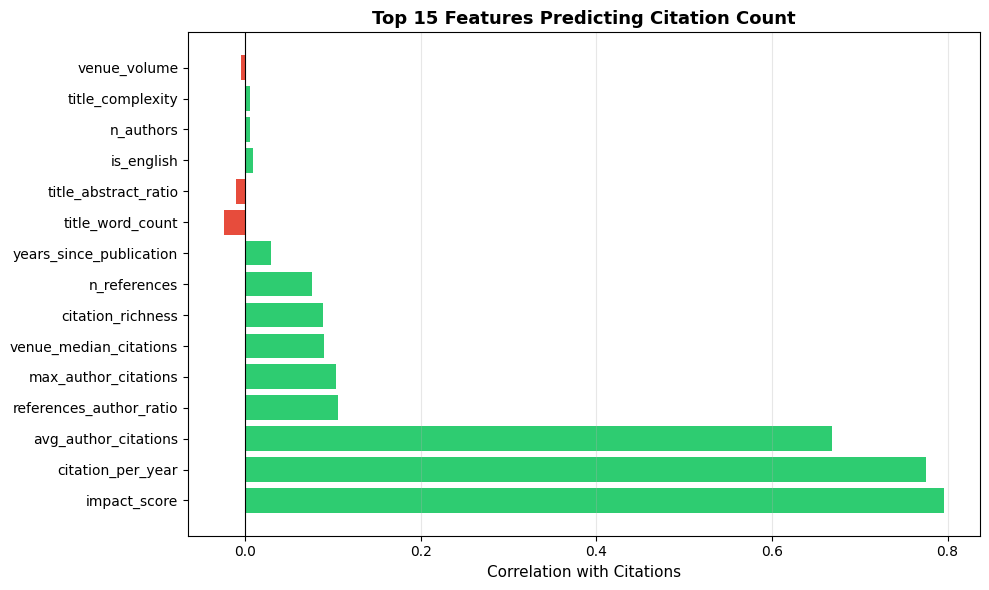


 FEATURE CORRELATION SUMMARY:
   Strong predictors (|corr| > 0.4): 3
   Moderate predictors (0.2 < |corr| ≤ 0.4): 0
   Weak predictors (|corr| ≤ 0.2): 14


In [ ]:
# Load features into pandas for correlation analysis
df_features = con.sql("""
SELECT *
FROM papers_with_features
USING SAMPLE 50000
""").df()

# Filter where target > 0
df_features = df_features[df_features['target_variable'] > 0]

print(f"Loaded {len(df_features):,} papers for analysis")

# Select numeric features
numeric_features = [
    'title_word_count', 'abstract_word_count', 'title_abstract_ratio',
    'title_complexity', 'abstract_complexity',
    'n_authors', 'avg_author_citations', 
    'max_author_citations',
    'n_references', 'references_author_ratio', 'citation_richness',
    'years_since_publication', 
    'citation_per_year', 'impact_score',
    'venue_median_citations', 'venue_volume', 'is_top_venue', 'is_english'
]

# Compute correlations
correlations = {}
for feat in numeric_features:
    if feat in df_features.columns:
        corr = df_features[[feat, 'target_variable']].corr().iloc[0, 1]
        correlations[feat] = corr

# Create dataframe and sort
corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', key=abs, ascending=False)

print("\nTOP 15 MOST CORRELATED FEATURES WITH CITATIONS:")
print(corr_df.head(15).to_string(index=False))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 6))
top_corr = corr_df.head(15)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_corr['Correlation']]
bars = ax.barh(range(len(top_corr)), top_corr['Correlation'], color=colors)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['Feature'], fontsize=10)
ax.set_xlabel('Correlation with Citations', fontsize=11)
ax.set_title('Top 15 Features Predicting Citation Count', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance summary
print("\n FEATURE CORRELATION SUMMARY:")
print(f"   Strong predictors (|corr| > 0.4): {len(corr_df[abs(corr_df['Correlation']) > 0.4])}")
print(f"   Moderate predictors (0.2 < |corr| ≤ 0.4): {len(corr_df[(abs(corr_df['Correlation']) > 0.2) & (abs(corr_df['Correlation']) <= 0.4)])}")
print(f"   Weak predictors (|corr| ≤ 0.2): {len(corr_df[abs(corr_df['Correlation']) <= 0.2])}")

In [ ]:
# df = con.sql(f"""
#     SELECT
#         ARRAY_LENGTH(authors) AS n_authors,
#         ARRAY_LENGTH(keywords) AS n_keywords,
#         ARRAY_LENGTH("references") AS n_references,
#         TRY_CAST(page_end AS INT) - TRY_CAST(page_start AS INT) AS page_count,
#         LENGTH(abstract) AS abstract_length,
#         n_citation
#     FROM read_parquet('{PARQUET}')
#     WHERE n_citation IS NOT NULL
#     USING SAMPLE 20000
# """).df().dropna()

# sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Feature Correlations")
# plt.tight_layout()
# plt.show()

##  FEATURE INTERACTIONS & SEGMENTATION

 VENUE TIER ANALYSIS
           target_variable                         citation_per_year  \
                     count    mean median      std              mean   
venue_tier                                                             
elite                  167  494.08  141.0  2986.07         83.230003   
high                  1159  200.38   61.0   911.19         21.700001   
low                  14484   14.25    7.0    47.38          2.700000   
medium               30888   42.37   22.0   406.51          7.400000   

           n_references  
                   mean  
venue_tier               
elite             23.09  
high              20.12  
low                6.61  
medium            13.66  


C:\Users\Alessio\AppData\Local\Temp\ipykernel_31196\2375320306.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features_sorted, x='venue_tier', y='target_variable', ax=axes[0], palette='Set2')
C:\Users\Alessio\AppData\Local\Temp\ipykernel_31196\2375320306.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_features_sorted, x='venue_tier', y='citation_per_year', ax=axes[1], palette='Set3')


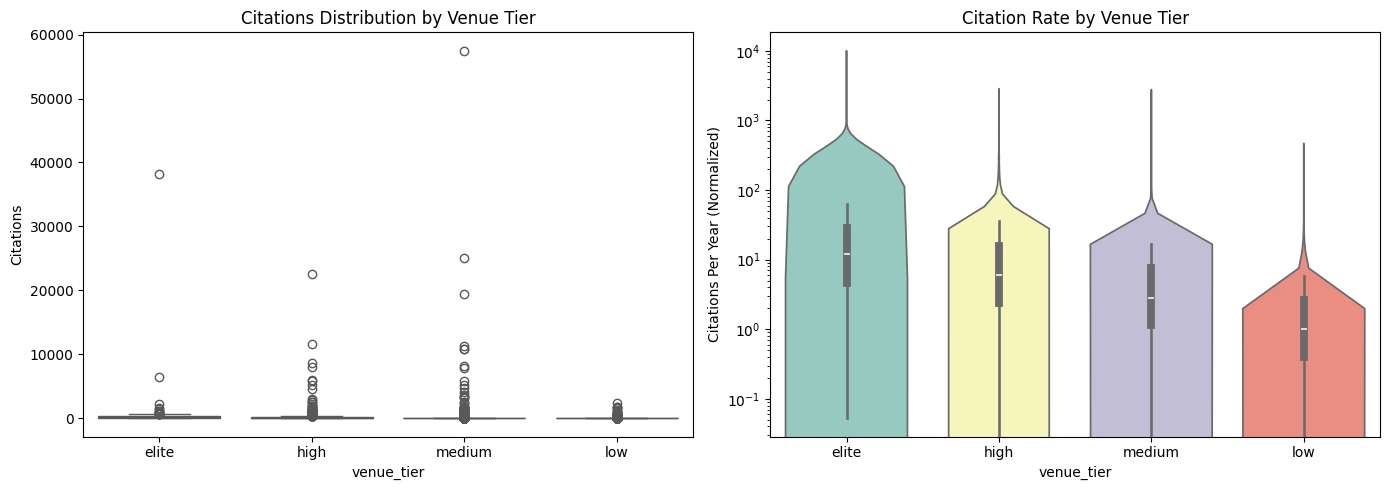


👥 AUTHOR REPUTATION TIERS
            target_variable               n_authors
                      count   mean median      mean
author_tier                                        
Emerging                868   2.68    2.0      1.93
Mid-Career             1779   8.70    8.0      2.31
Established           10717  17.39   13.0      2.70
Star                  32535  40.55   19.0      3.79


C:\Users\Alessio\AppData\Local\Temp\ipykernel_31196\2375320306.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  author_analysis = df_features.groupby('author_tier').agg({


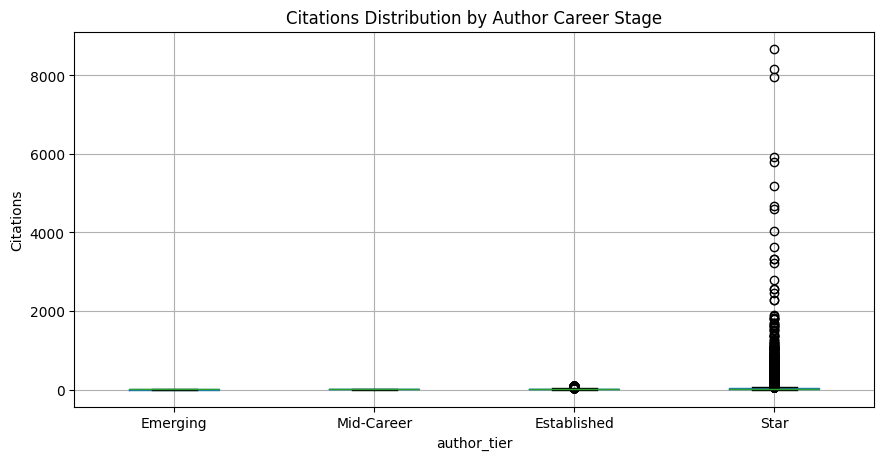


TEMPORAL TRENDS
                target_variable               citation_per_year
                          count   mean median              mean
publication_era                                                
2000-2009                  9126  54.15   19.0              2.89
2010-2019                 19809  37.50   17.0              4.55
2020+                     13918  25.45   15.0             13.13
pre-2000                   3845  62.05   20.0              1.97


C:\Users\Alessio\AppData\Local\Temp\ipykernel_31196\2375320306.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='publication_era', y='target_variable', ax=ax1, palette='Set1')
C:\Users\Alessio\AppData\Local\Temp\ipykernel_31196\2375320306.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp_norm, x='publication_era', y='citation_per_year', ax=ax2, palette='Set2')


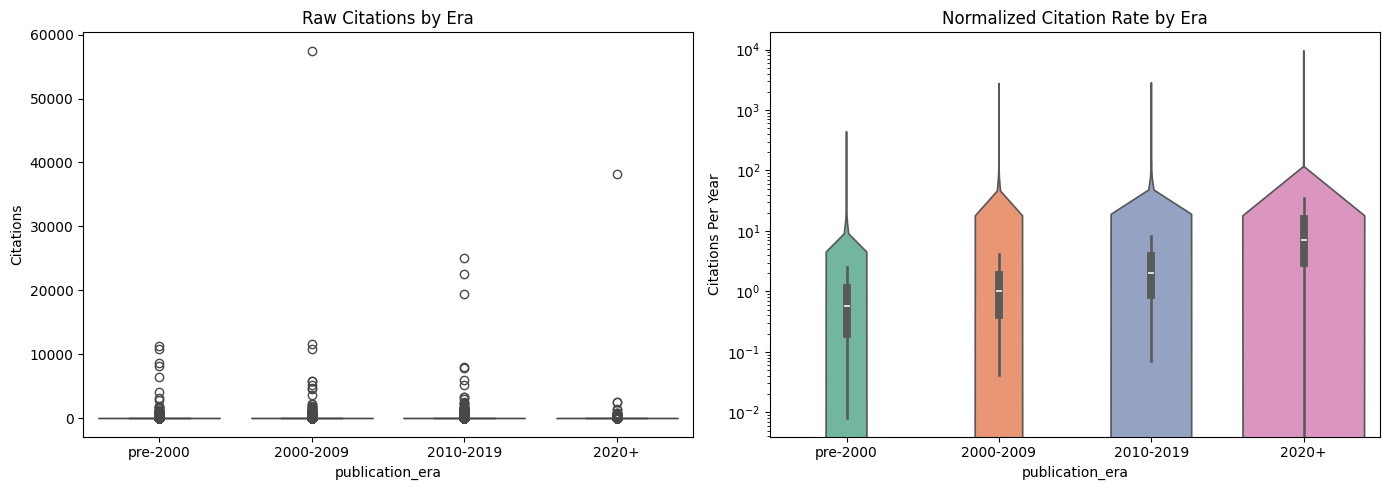


 VENUE x AUTHOR INTERACTION
                        count   mean
venue_tier author_tier              
elite      Emerging         1    5.0
           Mid-Career       0    NaN
           Established      7   25.7
           Star           144  239.2
high       Emerging        10    2.5
           Mid-Career      13   12.6
           Established    103   37.3
           Star           961  174.6
low        Emerging       558    2.5
           Mid-Career     867    7.2
           Established   4085   10.6
           Star          8798   16.7
medium     Emerging       299    2.9
           Mid-Career     899   10.1
           Established   6522   21.3
           Star         22632   42.9


C:\Users\Alessio\AppData\Local\Temp\ipykernel_31196\2375320306.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction = df_features.groupby(['venue_tier', 'author_tier'])['target_variable'].agg(['count', 'mean']).round(1)


In [ ]:
# 1. Venue Tier Impact
print(" VENUE TIER ANALYSIS")
venue_analysis = df_features.groupby('venue_tier').agg({
    'target_variable': ['count', 'mean', 'median', 'std'],
    'citation_per_year': 'mean',
    'n_references': 'mean'
}).round(2)
print(venue_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
venue_order = ['elite', 'high', 'medium', 'low']
df_features_sorted = df_features.copy()
df_features_sorted['venue_tier'] = pd.Categorical(df_features_sorted['venue_tier'], categories=venue_order, ordered=True)

sns.boxplot(data=df_features_sorted, x='venue_tier', y='target_variable', ax=axes[0], palette='Set2')
axes[0].set_ylabel('Citations')
axes[0].set_title('Citations Distribution by Venue Tier')

sns.violinplot(data=df_features_sorted, x='venue_tier', y='citation_per_year', ax=axes[1], palette='Set3')
axes[1].set_ylabel('Citations Per Year (Normalized)')
axes[1].set_title('Citation Rate by Venue Tier')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# 2. Author Reputation Impact
print("\n👥 AUTHOR REPUTATION TIERS")
df_features['author_tier'] = pd.cut(df_features['max_author_citations'], 
                                     bins=[0, 5, 20, 100, 10000],
                                     labels=['Emerging', 'Mid-Career', 'Established', 'Star'])

author_analysis = df_features.groupby('author_tier').agg({
    'target_variable': ['count', 'mean', 'median'],
    'n_authors': 'mean'
}).round(2)
print(author_analysis)

df_features.boxplot(column='target_variable', by='author_tier', figsize=(10, 5))
plt.suptitle('')
plt.title('Citations Distribution by Author Career Stage')
plt.ylabel('Citations')
plt.show()

# 3. Era Analysis
print("\nTEMPORAL TRENDS")
era_analysis = df_features.groupby('publication_era').agg({
    'target_variable': ['count', 'mean', 'median'],
    'citation_per_year': 'mean'
}).round(2)
print(era_analysis)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

era_order = ['pre-2000', '2000-2009', '2010-2019', '2020+']
df_temp = df_features.copy()
df_temp['publication_era'] = pd.Categorical(df_temp['publication_era'], categories=era_order, ordered=True)
df_temp = df_temp.sort_values('publication_era')

sns.boxplot(data=df_temp, x='publication_era', y='target_variable', ax=ax1, palette='Set1')
ax1.set_ylabel('Citations')
ax1.set_title('Raw Citations by Era')

df_temp_norm = df_temp[df_temp['citation_per_year'].notna()]
sns.violinplot(data=df_temp_norm, x='publication_era', y='citation_per_year', ax=ax2, palette='Set2')
ax2.set_ylabel('Citations Per Year')
ax2.set_title('Normalized Citation Rate by Era')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# 4. Complex Interactions
print("\n VENUE x AUTHOR INTERACTION")
interaction = df_features.groupby(['venue_tier', 'author_tier'])['target_variable'].agg(['count', 'mean']).round(1)
print(interaction)

Building comprehensive correlation matrix with ALL features...
Combined dataset shape: (35136, 22)
Features included: ['title_word_count', 'abstract_word_count', 'title_abstract_ratio', 'title_complexity', 'abstract_complexity', 'n_authors', 'avg_author_citations', 'max_author_citations', 'n_references', 'references_author_ratio', 'citation_richness', 'years_since_publication', 'citation_per_year', 'impact_score', 'venue_median_citations', 'venue_volume', 'is_top_venue', 'is_english', 'target_variable', 'n_keywords', 'page_count', 'abstract_length']


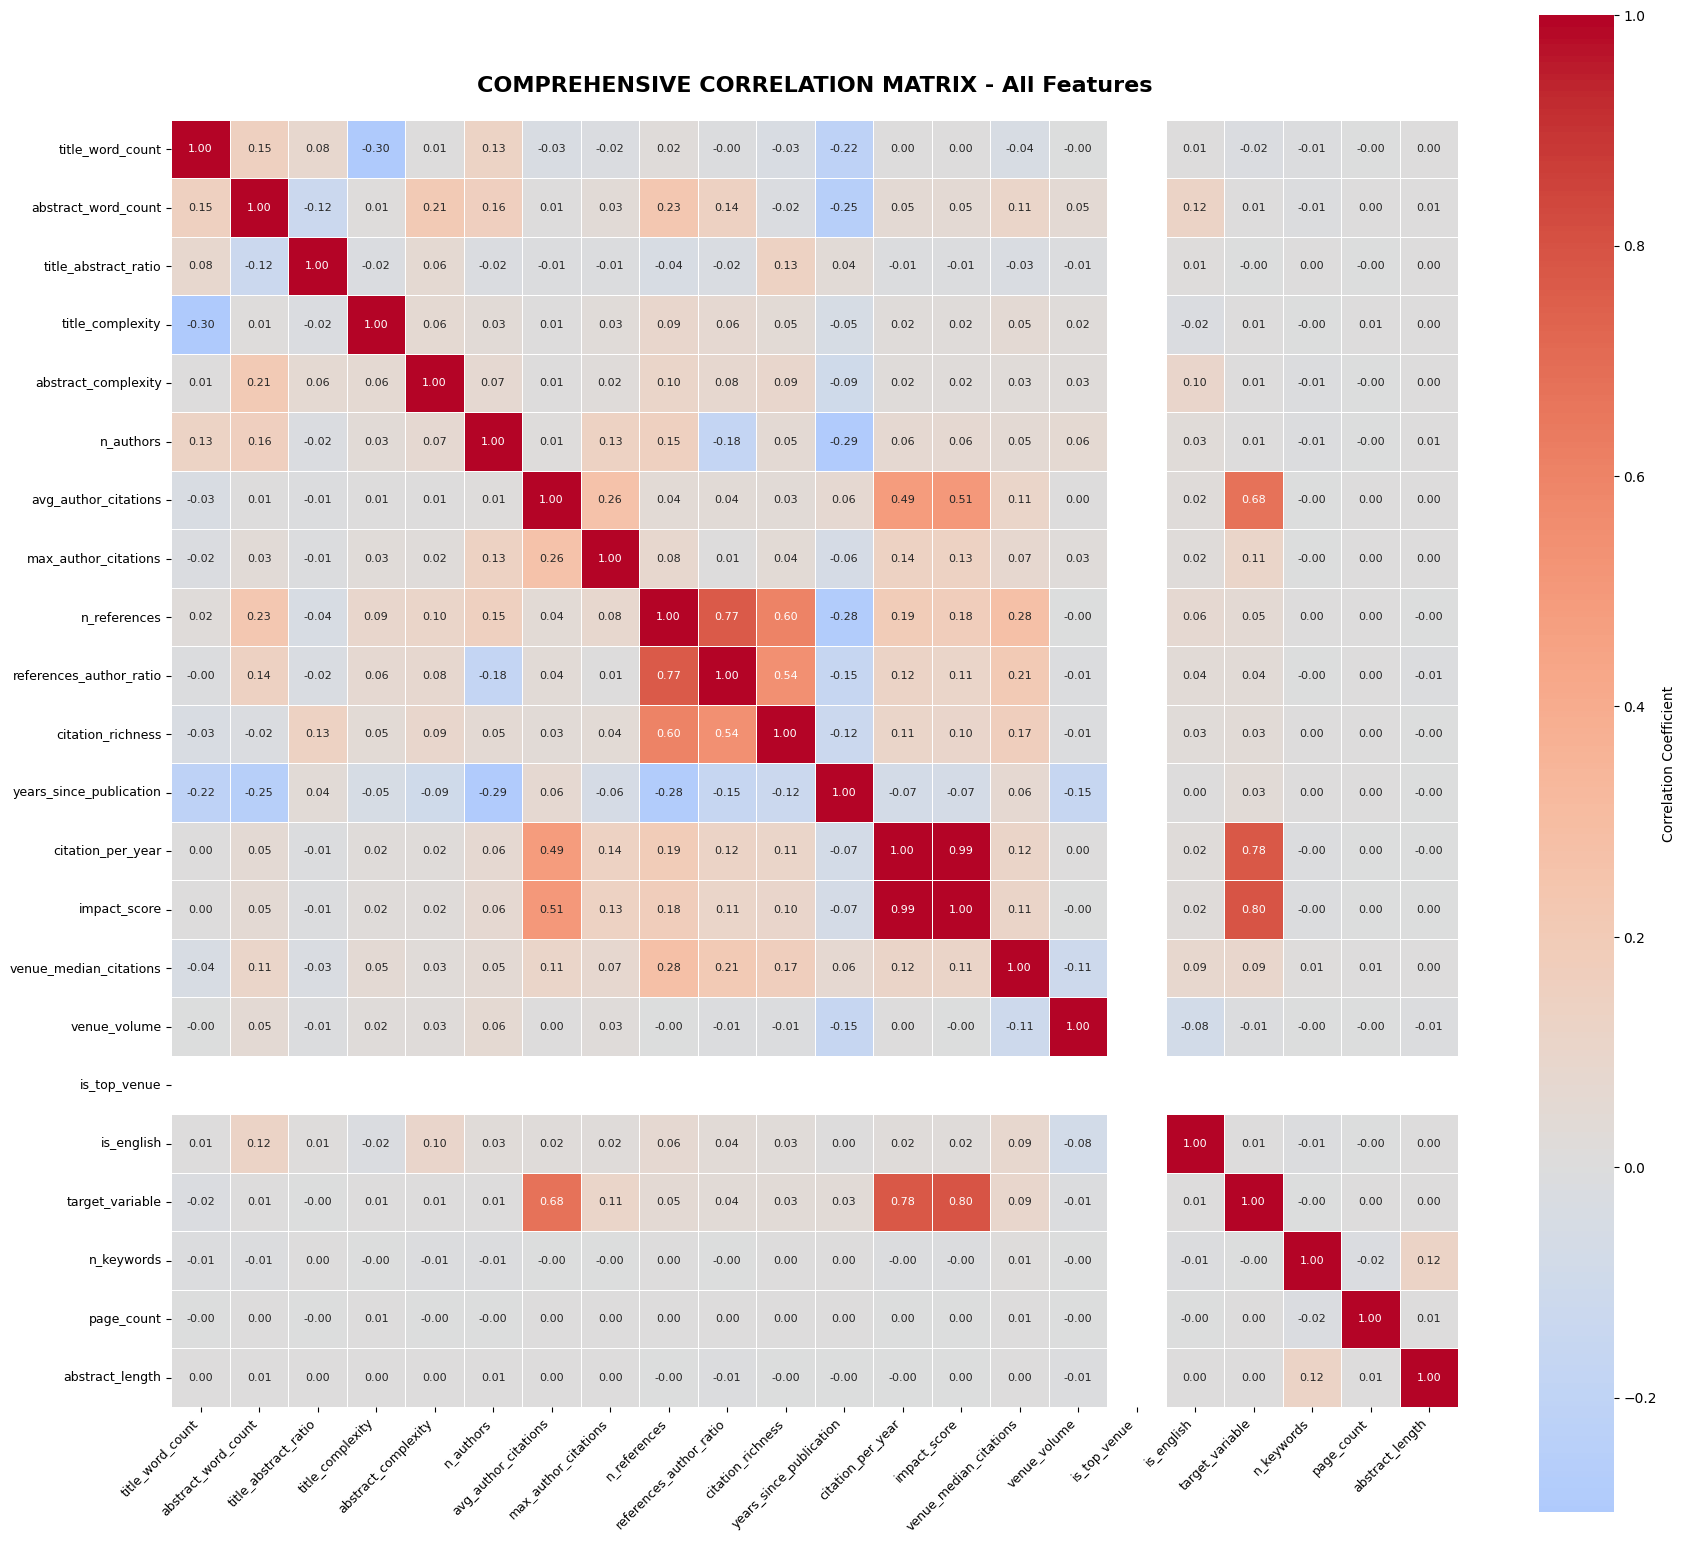


CORRELATION WITH TARGET VARIABLE (n_citation)

All features ranked by correlation strength with citations:
  ★★★ impact_score                   +0.7959
  ★★★ citation_per_year              +0.7768
  ★★★ avg_author_citations           +0.6783
  ★ max_author_citations           +0.1058
  ★ venue_median_citations         +0.0868
  ★ n_references                   +0.0474
  ★ references_author_ratio        +0.0393
  ★ citation_richness              +0.0332
  ★ years_since_publication        +0.0320
  ★ title_word_count               -0.0168
  ★ is_english                     +0.0096
  ★ title_complexity               +0.0089
  ★ venue_volume                   -0.0077
  ★ abstract_complexity            +0.0072
  ★ abstract_word_count            +0.0067
  ★ n_authors                      +0.0067
  ★ n_keywords                     -0.0042
  ★ title_abstract_ratio           -0.0037
  ★ abstract_length                +0.0022
  ★ page_count                     +0.0007
  ★ is_top_venue          

In [ ]:
# COMPREHENSIVE CORRELATION MATRIX - All Features Combined
print("Building comprehensive correlation matrix with ALL features...")

# Load all features from papers_with_features
df_all_features = con.sql("""
SELECT 
    title_word_count,
    abstract_word_count,
    title_abstract_ratio,
    title_complexity,
    abstract_complexity,
    n_authors,
    avg_author_citations,
    max_author_citations,
    n_references,
    references_author_ratio,
    citation_richness,
    years_since_publication,
    citation_per_year,
    impact_score,
    venue_median_citations,
    venue_volume,
    is_top_venue,
    is_english,
    target_variable
FROM papers_with_features
USING SAMPLE 50000
""").df()

# Add features from the raw parquet (that might have additional info)
df_raw = con.sql(f"""
    SELECT
        ARRAY_LENGTH(authors) AS n_authors_raw,
        ARRAY_LENGTH(keywords) AS n_keywords,
        ARRAY_LENGTH("references") AS n_references_raw,
        TRY_CAST(page_end AS INT) - TRY_CAST(page_start AS INT) AS page_count,
        LENGTH(abstract) AS abstract_length,
        n_citation
    FROM read_parquet('{PARQUET}')
    WHERE n_citation IS NOT NULL
    USING SAMPLE 50000
""").df().dropna()

# Select numeric columns from raw that are not exact duplicates
# (n_authors and n_references are already in df_all_features, so we skip the _raw versions)
additional_features = df_raw[['n_keywords', 'page_count', 'abstract_length']].copy()

# Remove rows with NaN in the main dataframe
df_all_features = df_all_features.dropna()

# Merge if shapes allow (take intersection of indices)
if len(df_all_features) > 0 and len(additional_features) > 0:
    # Align sizes - take minimum
    min_size = min(len(df_all_features), len(additional_features))
    df_all_features = df_all_features.iloc[:min_size].reset_index(drop=True)
    additional_features = additional_features.iloc[:min_size].reset_index(drop=True)
    
    # Combine all features
    df_combined = pd.concat([df_all_features, additional_features], axis=1)
else:
    df_combined = df_all_features

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Features included: {list(df_combined.columns)}")

# === FINAL COMPREHENSIVE CORRELATION MATRIX ===
# Calculate correlation matrix
correlation_matrix = df_combined.corr()

# Create large heatmap
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('COMPREHENSIVE CORRELATION MATRIX - All Features', 
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# === CORRELATION WITH TARGET ===
print("\n" + "="*80)
print("CORRELATION WITH TARGET VARIABLE (n_citation)")
print("="*80)

target_corr = correlation_matrix['target_variable'].drop('target_variable').sort_values(key=abs, ascending=False)
print("\nAll features ranked by correlation strength with citations:")
for feat, corr_val in target_corr.items():
    stars = "★★★" if abs(corr_val) > 0.4 else "★★" if abs(corr_val) > 0.2 else "★"
    print(f"  {stars} {feat:30} {corr_val:+.4f}")

# === FEATURE GROUPING INSIGHTS ===
print("\n" + "="*80)
print("FEATURE STRENGTH SUMMARY")
print("="*80)
strong = len(target_corr[abs(target_corr) > 0.4])
moderate = len(target_corr[(abs(target_corr) > 0.2) & (abs(target_corr) <= 0.4)])
weak = len(target_corr[abs(target_corr) <= 0.2])

print(f"Strong predictors (|r| > 0.40):      {strong:2d} features")
print(f"Moderate predictors (0.2 < |r| ≤ 0.40): {moderate:2d} features")
print(f"Weak predictors (|r| ≤ 0.20):        {weak:2d} features")
print(f"Total features analyzed:             {len(target_corr):2d} features")

# === INTER-FEATURE CORRELATIONS ===
print("\n" + "="*80)
print("HIGH INTER-FEATURE CORRELATIONS (|r| > 0.7) - Potential Multicollinearity")
print("="*80)

# Find highly correlated feature pairs (excluding diagonal and duplicates)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            feat1 = correlation_matrix.columns[i]
            feat2 = correlation_matrix.columns[j]
            corr_pairs.append((feat1, feat2, corr_val))

corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

if corr_pairs:
    for f1, f2, corr in corr_pairs[:15]:  # Top 15
        print(f"  {f1:25} <-> {f2:25} | r = {corr:+.4f}")
else:
    print("  No highly correlated feature pairs found (r > 0.7)")

print("\n" + "="*80)

## EXPORT & SUMMARY

Esportiamo i risultati del feature engineering per uso in modeling:

In [ ]:
# Export complete feature set
con.sql("COPY papers_with_features TO 'papers_with_features.parquet' (FORMAT PARQUET)")
print(" Exported: papers_with_features.parquet")

# Export top cited papers
con.sql("""
COPY (
    SELECT * FROM papers_with_features
    ORDER BY target_variable DESC
    LIMIT 100
) TO 'top_cited_papers_features.parquet' (FORMAT PARQUET)
""")
print("Exported: top_cited_papers_features.parquet")

# Generate summary report
print("\n" + "="*80)
print("FEATURE ENGINEERING FINAL REPORT")
print("="*80)

print(f"\nTotal Papers with Features: {len(df_features):,}")
print(f"Total Features Created: {len(numeric_features)} numeric + 5 categorical")
print(f"\n TOP 5 PREDICTIVE FEATURES:")
for i, row in corr_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']:30} | Corr: {row['Correlation']:+.4f}")

print(f"\n KEY INSIGHTS:")
print(f"   • Strong venues get {df_features[df_features['venue_tier']=='elite']['target_variable'].mean():.0f} citations vs {df_features[df_features['venue_tier']=='low']['target_variable'].mean():.0f} for weak")
print(f"   • Papers with star authors: {df_features[df_features['max_author_citations']>100]['target_variable'].mean():.0f} cit. vs {df_features[df_features['max_author_citations']<=5]['target_variable'].mean():.0f} for emerging")
print(f"   • Pre-2000 papers: {df_features[df_features['year']<2000]['target_variable'].mean():.0f} citations (mature)")
print(f"   • 2020+ papers: {df_features[df_features['year']>=2020]['target_variable'].mean():.0f} citations (incomplete)")

print("\n" + "="*80)

 Exported: papers_with_features.parquet
Exported: top_cited_papers_features.parquet

FEATURE ENGINEERING FINAL REPORT

Total Papers with Features: 46,698
Total Features Created: 18 numeric + 5 categorical

 TOP 5 PREDICTIVE FEATURES:
   14. impact_score                   | Corr: +0.7959
   13. citation_per_year              | Corr: +0.7749
   7. avg_author_citations           | Corr: +0.6686
   10. references_author_ratio        | Corr: +0.1057
   8. max_author_citations           | Corr: +0.1031

 KEY INSIGHTS:
   • Strong venues get 494 citations vs 14 for weak
   • Papers with star authors: 49 cit. vs 3 for emerging
   • Pre-2000 papers: 62 citations (mature)
   • 2020+ papers: 25 citations (incomplete)



In [ ]:
# %pip install -q torch torchvision torchaudio
# %pip install -q torch-geometric scikit-learn

# TRAINING

In [ ]:
# import os
# import torch
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from torch_geometric.utils import to_undirected


# REBUILD_SPLITS = False


# SPLIT_DIR   = "splits_gcn"
# NODE_PATH   = f"{SPLIT_DIR}/node_df.parquet"
# EDGE_PATH   = f"{SPLIT_DIR}/edge_df.parquet"
# SCALER_MEAN = f"{SPLIT_DIR}/scaler_mean.npy"
# SCALER_STD  = f"{SPLIT_DIR}/scaler_std.npy"


# num_cols = [
#     'n_authors', 'avg_author_citations', 'max_author_citations',
#     'n_references', 'references_author_ratio', 'citation_richness',
#     'years_since_publication', 'citation_per_year', 'impact_score',
#     'venue_median_citations', 'venue_volume', 'is_top_venue', 'is_english'
# ]


# if REBUILD_SPLITS or not os.path.exists(NODE_PATH):
#     os.makedirs(SPLIT_DIR, exist_ok=True)

#     sample_n = 15000

#     # 1. Sample nodes with a fixed seed for reproducibility
#     node_df = con.sql(f"""
#         SELECT id, year,
#                n_authors, avg_author_citations, max_author_citations,
#                n_references, references_author_ratio, citation_richness,
#                years_since_publication, citation_per_year, impact_score,
#                venue_median_citations, venue_volume, is_top_venue, is_english
#         FROM papers_with_features
#         WHERE id IS NOT NULL AND TRIM(id) <> ''
#           AND year IS NOT NULL
#         USING SAMPLE reservoir({sample_n})
#     """).df().reset_index(drop=True)

#     node_df['node_idx'] = node_df.index
#     con.register("sampled_papers", node_df[['id']])

#     # 2. Retrieve edges between sampled papers
#     edge_df = con.sql("""
#         SELECT p.id AS src_id, ref AS dst_id
#         FROM papers p
#         CROSS JOIN UNNEST(p."references") AS t(ref)
#         JOIN sampled_papers sp_src ON p.id  = sp_src.id
#         JOIN sampled_papers sp_dst ON ref   = sp_dst.id
#     """).df().drop_duplicates().reset_index(drop=True)

#     if edge_df.empty:
#         raise RuntimeError("No citations found among the sampled papers.")

#     edge_df = (edge_df
#         .merge(node_df[['id', 'node_idx']], left_on='src_id', right_on='id')
#         .rename(columns={'node_idx': 'src_idx'}).drop(columns=['id'])
#         .merge(node_df[['id', 'node_idx']], left_on='dst_id', right_on='id')
#         .rename(columns={'node_idx': 'dst_idx'}).drop(columns=['id'])
#     )

#     # 3. Temporal split on edges — prevents data leakage
#     edge_df = edge_df.merge(
#         node_df[['node_idx', 'year']].rename(columns={'node_idx': 'src_idx', 'year': 'src_year'}),
#         on='src_idx'
#     )

#     edge_df = edge_df.sort_values('src_year').reset_index(drop=True)
#     n         = len(edge_df)
#     train_end = int(n * 0.70)
#     val_end   = int(n * 0.85)

#     conditions = [
#         edge_df.index < train_end,
#         (edge_df.index >= train_end) & (edge_df.index < val_end),
#     ]
#     edge_df['split'] = np.select(conditions, ['train', 'val'], default='test')

#     print(f"Total edges: {n}")
#     print(edge_df['split'].value_counts().sort_index())
#     print(f"Max year train: {edge_df[edge_df.split=='train']['src_year'].max()}")
#     print(f"Min year val:   {edge_df[edge_df.split=='val']['src_year'].min()}")
#     print(f"Min year test:  {edge_df[edge_df.split=='test']['src_year'].min()}")

#     # 4. Normalisation — fit only on train nodes
#     train_node_ids = set(
#         edge_df[edge_df.split == 'train']['src_idx'].tolist() +
#         edge_df[edge_df.split == 'train']['dst_idx'].tolist()
#     )
#     train_mask = node_df['node_idx'].isin(train_node_ids)

#     features_raw = node_df[num_cols].to_numpy(dtype=float)
#     features_raw = np.nan_to_num(features_raw, nan=0.0, posinf=1e9, neginf=-1e9)

#     scaler = StandardScaler()
#     scaler.fit(features_raw[train_mask])
#     node_df[num_cols] = scaler.transform(features_raw)

#     # 5. Save
#     node_df.to_parquet(NODE_PATH, index=False)
#     edge_df.to_parquet(EDGE_PATH, index=False)
#     np.save(SCALER_MEAN, scaler.mean_)
#     np.save(SCALER_STD,  scaler.scale_)
#     print("Splits saved to", SPLIT_DIR)

# else:
#     print("Existing splits found, loading...")
#     node_df = pd.read_parquet(NODE_PATH)
#     edge_df = pd.read_parquet(EDGE_PATH)
#     print(f"Nodes: {len(node_df)} | Edges: {len(edge_df)}")
#     print(edge_df['split'].value_counts().sort_index())

## SPLIT

In [ ]:
import pyarrow.parquet as pq
import pandas as pd

INPUT_FILE = "papers_with_features_with_refs.parquet"

# Read schema without loading data
pf = pq.read_schema(INPUT_FILE)
print(f"Total columns: {len(pf.names)}\n")
print(f"{'Column':<45} {'Type':<20}")
print("-" * 65)
for name in pf.names:
    print(f"{name:<45} {str(pf.field(name).type):<20}")

# Load only first 3 rows to see actual values
print("\n--- Sample values (3 rows) ---")
sample = pd.read_parquet(INPUT_FILE).head(3)
for col in sample.columns:
    print(f"\n{col}: {sample[col].tolist()}")

Total columns: 33

Column                                        Type                
-----------------------------------------------------------------
id                                            string              
title                                         string              
references                                    list<element: string>
year                                          int64               
target_variable                               int64               
title_word_count                              int64               
abstract_word_count                           int64               
title_abstract_ratio                          float               
title_complexity                              float               
abstract_complexity                           float               
has_numbers_in_title                          int32               
has_numbers_in_abstract                       int32               
n_authors                                  

In [ ]:
leaky_features = [
    "citation_per_year",
    "impact_score",
    "citation_richness",
    "is_highly_cited_for_year",
    "avg_author_citations",
    "max_author_citations",
    "venue_median_citations",
    "years_since_publication",
    "n_references",           
    "references_author_ratio",
    "has_high_ref_count",     
]

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                        CONFIGURATION                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
INPUT_FILE = "papers_with_features_with_refs.parquet"  # ← file con references
OUTPUT_DIR = "model_splits"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Check if split files already exist
split_files_exist = all([
    os.path.exists(f"{OUTPUT_DIR}/train.parquet"),
    os.path.exists(f"{OUTPUT_DIR}/val.parquet"),
    os.path.exists(f"{OUTPUT_DIR}/test.parquet")
])

if split_files_exist:
    print(f"Split files already exist in '{OUTPUT_DIR}'. Skipping creation.")
else:
    print("Loading dataset...")
    df = pd.read_parquet(INPUT_FILE)

    # ── 1. Temporal sorting ───────────────────────────────────────────────
    df = df.dropna(subset=["year"]).copy()
    df = df.sort_values("year").reset_index(drop=True)

    # Sequential node_idx 0..N-1 (required by PyTorch Geometric)
    df["node_idx"] = np.arange(len(df), dtype=np.int32)

    # ── 2. Feature definition (NO TARGET NODE FEATURE PER LA LINK PREDICTION)
    
    # Lista di feature da ignorare (leaky_features va definita prima, es. leaky_features = [])
    leaky_features = getattr(globals(), 'leaky_features', []) 

    # Colonne strutturali che NON devono essere usate come feature numeriche (non vanno scalate)
    non_feature_cols = [
        "id",
        "n_citation",
        "node_idx",
        "split",
        "year",
        "title",
        "abstract",
        "venue",
        "publication_era",
        "venue_tier",
        "references",       # ← FONDAMENTALE: contiene i link (edge_index)
        "target_variable"   # Lo includiamo qui solo per evitare che venga scalato se fosse rimasto nel dataframe per sbaglio
    ]

    exclude_cols = set(non_feature_cols + list(leaky_features))

    # Seleziona solo le colonne numeriche valide
    safe_numeric_features = [
        col for col in df.columns
        if col not in exclude_cols
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    print(f"\nSafe numeric features selected ({len(safe_numeric_features)}):")
    for f in safe_numeric_features[:5]:
        print(f"  ✓  {f}")
    if len(safe_numeric_features) > 5:
        print("  ... e altre")

    # ── 3. Temporal splitting (Train <= 2020, Val 2021-2022, Test >= 2023) ───────────────
    df["split"] = ""
    
    df.loc[df["year"] <= 2020, "split"] = "train"
    df.loc[(df["year"] >= 2021) & (df["year"] <= 2022), "split"] = "val"
    df.loc[df["year"] >= 2023, "split"] = "test"

    print("\nSplit distribution:")
    print(df["split"].value_counts().reindex(["train", "val", "test"]))
    print(f"  Train years : {df.loc[df['split']=='train', 'year'].min()} – "
          f"{df.loc[df['split']=='train', 'year'].max()}")
    print(f"  Val years   : {df.loc[df['split']=='val',   'year'].min()} – "
          f"{df.loc[df['split']=='val',   'year'].max()}")
    print(f"  Test years  : {df.loc[df['split']=='test',  'year'].min()} – "
          f"{df.loc[df['split']=='test',  'year'].max()}")

    # ── 4. Strict scaling (fit ONLY on train, transform val/test) ────────
    X_train = df.loc[df["split"] == "train", safe_numeric_features].to_numpy()
    X_val   = df.loc[df["split"] == "val",   safe_numeric_features].to_numpy()
    X_test  = df.loc[df["split"] == "test",  safe_numeric_features].to_numpy()

    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)
    X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    # Cast a float64 per sicurezza e assegnazione
    for col in safe_numeric_features:
        df[col] = df[col].astype("float64")

    df.loc[df["split"] == "train", safe_numeric_features] = X_train_scaled
    df.loc[df["split"] == "val",   safe_numeric_features] = X_val_scaled
    df.loc[df["split"] == "test",  safe_numeric_features] = X_test_scaled

    # ── 5. Save files ─────────────────────────────────────────────────────
    
    # Colonne da mantenere nel file salvato (features + struttura + link)
    keep_cols = safe_numeric_features + [
        "id",
        "node_idx",
        "split",
        "year",
        "references",       # ← vitale per costruire gli edge_index (archi) successivamente
    ]

    # Sicurezza extra: rimuove eventuali colonne duplicate mantenendo l'ordine
    keep_cols = list(dict.fromkeys(keep_cols))

    print("\nSaving split files...")
    df.loc[df["split"] == "train", keep_cols].to_parquet(
        f"{OUTPUT_DIR}/train.parquet", index=False)
    df.loc[df["split"] == "val",   keep_cols].to_parquet(
        f"{OUTPUT_DIR}/val.parquet",   index=False)
    df.loc[df["split"] == "test",  keep_cols].to_parquet(
        f"{OUTPUT_DIR}/test.parquet",  index=False)

    np.save(f"{OUTPUT_DIR}/scaler_mean.npy",  scaler.mean_)
    np.save(f"{OUTPUT_DIR}/scaler_scale.npy", scaler.scale_)

    print(f"\n✓ Done. Files saved in '{OUTPUT_DIR}/'")
    print(f"   Node Features        : {len(safe_numeric_features)}")
    print(f"   Structural columns   : id, node_idx, split, year")
    print(f"   Graph Edges column   : references")
    print(f"   Scaler saved         : scaler_mean.npy, scaler_scale.npy")

Loading dataset...

Safe numeric features selected (25):
  ✓  title_word_count
  ✓  abstract_word_count
  ✓  title_abstract_ratio
  ✓  title_complexity
  ✓  abstract_complexity
  ... e altre

Split distribution:
split
train    4920858
val       767458
test     1041512
Name: count, dtype: int64
  Train years : 0 – 2020
  Val years   : 2021 – 2022
  Test years  : 2023 – 2027

Saving split files...

✓ Done. Files saved in 'model_splits/'
   Node Features        : 25
   Structural columns   : id, node_idx, split, year
   Graph Edges column   : references
   Scaler saved         : scaler_mean.npy, scaler_scale.npy


In [ ]:
# import pyarrow.parquet as pq

# # Reread LOAD_COLS from the current schema of the new Parquet files
# pf_new = pq.read_schema(f"{OUTPUT_DIR}/train.parquet")
# LOAD_COLS = [c for c in pf_new.names if c not in {"split"}]

# print("LOAD_COLS updated:", LOAD_COLS)

# train_df = load_and_sample(f"{OUTPUT_DIR}/train.parquet", TRAIN_SAMPLE, LOAD_COLS)
# val_df   = load_and_sample(f"{OUTPUT_DIR}/val.parquet",   VAL_SAMPLE,   LOAD_COLS)
# test_df  = load_and_sample(f"{OUTPUT_DIR}/test.parquet",  TEST_SAMPLE,  LOAD_COLS)

# train_df

# CELLA DA ESEGUIRE PER CARICARE GLI SPLIT

In [ ]:
import polars as pl

# Carica i file parquet come DataFrame Polars
train_df = pl.read_parquet('model_splits/train.parquet')
val_df = pl.read_parquet('model_splits/val.parquet')
test_df = pl.read_parquet('model_splits/test.parquet')

train_df

FileNotFoundError: No such file or directory (os error 2): model_splits/train.parquet

## Preparation for LGBM and XGBoost

In [ ]:
# Cell 0 — Shared data construction
# Run this once before LGBM and XGBoost cells.
# Produces: X_train_xgb, X_val_xgb, X_test_xgb, y_train_xgb, y_val_xgb, y_test_xgb, feature_names_xgb

import polars as pl
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt


# Fraction of edges to sample per split — reduce if RAM is tight
FRACTION_TRAIN = 0.20   # ~6M pairs
FRACTION_VAL   = 0.40   # ~3.6M pairs
FRACTION_TEST  = 0.50   # ~5M pairs


# -- Section 0: Load pre-processed parquet splits -----------------------------

all_df = pl.concat([train_df, val_df, test_df]).sort("node_idx")

num_train_nodes = int(train_df["node_idx"].max()) + 1
num_val_nodes   = int(max(train_df["node_idx"].max(), val_df["node_idx"].max())) + 1
num_total_nodes = int(all_df["node_idx"].max()) + 1

print(f"  Train nodes: {num_train_nodes:,}")
print(f"  Val nodes  : {num_val_nodes:,}")
print(f"  Total nodes: {num_total_nodes:,}")

id_to_idx = all_df.select(["id", "node_idx"])


# -- Section 1: Node feature matrix -------------------------------------------
# Each split only sees features of nodes that exist at that point in time.
exclude_cols = ["id", "node_idx", "split", "year", "references", "target_variable"]
feature_cols = [c for c in all_df.columns if c not in exclude_cols]

print(f"\nBuilding feature matrix: {num_total_nodes:,} nodes × {len(feature_cols)} features...")
node_feats_full = all_df.select(feature_cols).to_numpy()
node_feats_full = np.nan_to_num(
    node_feats_full, nan=0.0, posinf=0.0, neginf=0.0
).astype(np.float32)

node_feats_train = node_feats_full[:num_train_nodes]
node_feats_val   = node_feats_full[:num_val_nodes]
node_feats_test  = node_feats_full[:num_total_nodes]


# -- Section 2: Positive edge extraction --------------------------------------
# Edge (src → dst) means "paper src cites paper dst".
# Edges pointing to future nodes are filtered out to prevent leakage.
def get_edge_index(split_df, max_dst_node):
    edges = (
        split_df.select(["node_idx", "references"])
        .explode("references")
        .drop_nulls()
        .rename({"node_idx": "src", "references": "target_id"})
    )
    edges = edges.join(id_to_idx, left_on="target_id", right_on="id", how="inner")
    edges = edges.rename({"node_idx": "dst"})
    edges = edges.filter(pl.col("dst") < max_dst_node)
    src_np = edges["src"].to_numpy()
    dst_np = edges["dst"].to_numpy()
    return torch.tensor(np.vstack([src_np, dst_np]), dtype=torch.long)


def subsample_edges(
    edge_index,
    fraction,
    n_bins_src=4,
    n_bins_dst=4,
    seed=42,
):
    """
    Stratified subsample su (src_degree_bin, dst_degree_bin).
    Preserva la distribuzione congiunta dei gradi — il segnale dominante
    per link prediction. Molto più stabile del random uniforme.
    """
    if fraction >= 1.0:
        return edge_index

    rng = np.random.default_rng(seed)
    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()
    n_edges = src.shape[0]

    # Gradi calcolati sul set di archi di questo split (coerente con il contesto temporale)
    src_deg = np.bincount(src)[src]
    dst_deg = np.bincount(dst)[dst]

    def qbin(values, n_bins):
        qs = np.linspace(0.0, 1.0, n_bins + 1)
        edges = np.unique(np.quantile(values, qs))
        if len(edges) <= 2:
            return np.zeros_like(values, dtype=np.int64)
        return np.clip(np.digitize(values, edges[1:-1], right=False), 0, len(edges) - 2)

    src_bin = qbin(src_deg, n_bins_src)
    dst_bin = qbin(dst_deg, n_bins_dst)
    strata  = src_bin * (dst_bin.max() + 1) + dst_bin

    target = max(1, int(n_edges * fraction))

    # Allocazione proporzionale + largest-remainder per il residuo da arrotondamento
    uniq, counts = np.unique(strata, return_counts=True)
    quotas_f = counts * (target / n_edges)
    quotas   = np.floor(quotas_f).astype(int)
    leftover = target - quotas.sum()
    if leftover > 0:
        give = np.argsort(-(quotas_f - quotas))[:leftover]
        quotas[give] += 1

    picks = []
    for s, q in zip(uniq, quotas):
        if q == 0:
            continue
        idx = np.where(strata == s)[0]
        q = min(q, len(idx))
        picks.append(rng.choice(idx, size=q, replace=False))

    keep = np.concatenate(picks)
    rng.shuffle(keep)
    return edge_index[:, torch.from_numpy(keep).long()]

print("Extracting positive edges...")
train_pos_full = get_edge_index(train_df, max_dst_node=num_train_nodes)
val_pos_full   = get_edge_index(val_df,   max_dst_node=num_val_nodes)
test_pos_full  = get_edge_index(test_df,  max_dst_node=num_total_nodes)

print("Applying stratified subsampling...")
train_pos = subsample_edges(train_pos_full, FRACTION_TRAIN, seed=42)
val_pos   = subsample_edges(val_pos_full,   FRACTION_VAL,   seed=43)
test_pos  = subsample_edges(test_pos_full,  FRACTION_TEST,  seed=44)

print(f"  Train: {train_pos.size(1):,} edges (out of {train_pos_full.size(1):,})")
print(f"  Val  : {val_pos.size(1):,} edges (out of {val_pos_full.size(1):,})")
print(f"  Test : {test_pos.size(1):,} edges (out of {test_pos_full.size(1):,})")


# -- Section 3: Temporal negative sampling ------------------------------------
# For each positive edge we sample one fake pair → balanced 50/50 dataset.
# Train negatives are guaranteed not to appear in val/test edge sets.
# Pairs are encoded as src * num_nodes + dst for O(1) lookup.
def sample_negatives_fast(known_edge_index, num_nodes, target_count, oversample=2.0, seed=42):
    rng = np.random.default_rng(seed)
    src_k = known_edge_index[0].numpy().astype(np.int64)
    dst_k = known_edge_index[1].numpy().astype(np.int64)
    known_codes = set((src_k * num_nodes + dst_k).tolist())

    collected_src, collected_dst = [], []
    remaining = target_count

    while remaining > 0:
        n_sample = int(remaining * oversample)
        src_rand = rng.integers(0, num_nodes, size=n_sample, dtype=np.int64)
        dst_rand = rng.integers(0, num_nodes, size=n_sample, dtype=np.int64)
        valid = src_rand != dst_rand
        src_rand, dst_rand = src_rand[valid], dst_rand[valid]
        codes = (src_rand * num_nodes + dst_rand).tolist()
        mask = np.array([c not in known_codes for c in codes], dtype=bool)
        src_rand, dst_rand = src_rand[mask], dst_rand[mask]
        take = min(remaining, len(src_rand))
        collected_src.append(src_rand[:take])
        collected_dst.append(dst_rand[:take])
        remaining -= take

    src_out = np.concatenate(collected_src).astype(np.int64)
    dst_out = np.concatenate(collected_dst).astype(np.int64)
    return torch.tensor(np.vstack([src_out, dst_out]), dtype=torch.long)


print("\nGenerating negative samples...")

neg_train = sample_negatives_fast(
    train_pos_full, num_nodes=num_train_nodes,
    target_count=train_pos.size(1), seed=42,
)
assert neg_train.size(1) == train_pos.size(1), "neg_train insufficient — increase oversample"
print(f"  neg_train: {neg_train.size(1):,}")

neg_val = sample_negatives_fast(
    torch.cat([train_pos_full, val_pos_full], dim=1),
    num_nodes=num_val_nodes,
    target_count=val_pos.size(1), seed=43,
)
assert neg_val.size(1) == val_pos.size(1), "neg_val insufficient — increase oversample"
print(f"  neg_val  : {neg_val.size(1):,}")

neg_test = sample_negatives_fast(
    torch.cat([train_pos_full, val_pos_full, test_pos_full], dim=1),
    num_nodes=num_total_nodes,
    target_count=test_pos.size(1), seed=44,
)
assert neg_test.size(1) == test_pos.size(1), "neg_test insufficient — increase oversample"
print(f"  neg_test : {neg_test.size(1):,}")


# -- Section 4: Tabular matrix construction -----------------------------------
# Each edge (src → dst) becomes a row of 50 values:
#   [feat_1_src ... feat_25_src | feat_1_dst ... feat_25_dst]
# Label 1 = real citation, 0 = fake pair.
def pairs_to_matrix(edge_index, node_feats):
    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()
    return np.hstack([node_feats[src], node_feats[dst]])


print("\nCreating tabular datasets...")

X_train_xgb = np.vstack([
    pairs_to_matrix(train_pos, node_feats_train),
    pairs_to_matrix(neg_train, node_feats_train),
])
y_train_xgb = np.concatenate([
    np.ones(train_pos.size(1),  dtype=np.int32),
    np.zeros(neg_train.size(1), dtype=np.int32),
])

X_val_xgb = np.vstack([
    pairs_to_matrix(val_pos, node_feats_val),
    pairs_to_matrix(neg_val, node_feats_val),
])
y_val_xgb = np.concatenate([
    np.ones(val_pos.size(1),  dtype=np.int32),
    np.zeros(neg_val.size(1), dtype=np.int32),
])

X_test_xgb = np.vstack([
    pairs_to_matrix(test_pos, node_feats_test),
    pairs_to_matrix(neg_test, node_feats_test),
])
y_test_xgb = np.concatenate([
    np.ones(test_pos.size(1),  dtype=np.int32),
    np.zeros(neg_test.size(1), dtype=np.int32),
])

feature_names_xgb = [f"src_{c}" for c in feature_cols] + [f"dst_{c}" for c in feature_cols]

print(f"  X_train : {X_train_xgb.shape}  ← {train_pos.size(1):,} positives + {neg_train.size(1):,} negatives")
print(f"  X_val   : {X_val_xgb.shape}  ← {val_pos.size(1):,} positives + {neg_val.size(1):,} negatives")
print(f"  X_test  : {X_test_xgb.shape}  ← {test_pos.size(1):,} positives + {neg_test.size(1):,} negatives")

# MODEL 1 --> pair (one paper cite another)

In [ ]:
import lightgbm as lgb
import time
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

assert 'X_train_xgb' in dir(), "Esegui prima la cella di costruzione dei dati (sezioni 0-4)!"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    LIGHTGBM — LINK PREDICTION                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("Training LightGBM with Early Stopping on Validation Set...")
scale_pos_weight_lgbm = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=6,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    min_child_samples=20,
    reg_lambda=1.0,
    objective="binary",
    metric="binary_logloss",
    scale_pos_weight=scale_pos_weight_lgbm,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# Callback per salvare la loss durante il training
lgbm_evals_result = {}

t0 = time.time()
lgbm_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val_xgb, y_val_xgb)],
    eval_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=0),
        lgb.record_evaluation(lgbm_evals_result),
    ],
)
lgbm_train_time = time.time() - t0
print(f"Training stopped at iteration : {lgbm_model.best_iteration_}")
print(f"Training time                 : {lgbm_train_time:.1f}s")


# --- Evaluation ---
print("\nEvaluating on the Test Set...")
lgbm_probs = lgbm_model.predict_proba(X_test_xgb)[:, 1]
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

print("\n--- LightGBM Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, lgbm_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, lgbm_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, lgbm_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, lgbm_preds, digits=4))


# --- Plot: Loss curve + Confusion Matrix + Feature Importance ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Subplot 1: Loss curve
train_loss = lgbm_evals_result["train"]["binary_logloss"]
val_loss   = lgbm_evals_result["val"]["binary_logloss"]
axes[0].plot(train_loss, label="Train logloss", color="mediumseagreen", linewidth=1.5)
axes[0].plot(val_loss,   label="Val logloss",   color="tomato",         linewidth=1.5)
axes[0].axvline(lgbm_model.best_iteration_ - 1, color="gray", linestyle="--", label=f"Best iter ({lgbm_model.best_iteration_})")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log Loss")
axes[0].set_title("LightGBM — Training Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Confusion Matrix
cm_lgbm = confusion_matrix(y_test_xgb, lgbm_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_lgbm).plot(cmap="Greens", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — LightGBM")

# Subplot 3: Feature Importance
lgbm_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "gain": lgbm_model.feature_importances_,
}).sort_values("gain", ascending=False).head(15)

axes[2].barh(lgbm_importance_df["feature"][::-1], lgbm_importance_df["gain"][::-1], color="mediumseagreen")
axes[2].set_title("Top 15 Feature Importances (Gain) — LightGBM")
axes[2].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

display(lgbm_importance_df.head(15))

# MODEL 2 -> XGBOOST

In [ ]:
# # ORIGINALE
# import numpy as np
# import torch
# from xgboost import XGBClassifier
# from torch_geometric.utils import negative_sampling
# from sklearn.metrics import (
#     roc_auc_score, average_precision_score, brier_score_loss,
#     classification_report, confusion_matrix, ConfusionMatrixDisplay,
# )

# # --- 1. Build node feature matrix (same features as the GCN) ---
# node_feats = node_df[num_cols].to_numpy(dtype=np.float32)
# node_feats = np.nan_to_num(node_feats, nan=0.0, posinf=0.0, neginf=0.0)

# # --- 2. Negative sampling for each split (mirrors the GCN protocol) ---
# torch.manual_seed(42)
# num_nodes = len(node_df)

# neg_train = negative_sampling(
#     edge_index=train_pos,
#     num_nodes=num_nodes,
#     num_neg_samples=train_pos.size(1),
# )
# neg_test = negative_sampling(
#     edge_index=torch.cat([train_pos, val_pos], dim=1),
#     num_nodes=num_nodes,
#     num_neg_samples=test_pos.size(1),
# )

# # --- 3. Turn an edge_index tensor into a pair feature matrix (src || dst) ---
# def pairs_to_matrix(edge_index):
#     src = edge_index[0].cpu().numpy()
#     dst = edge_index[1].cpu().numpy()
#     return np.hstack([node_feats[src], node_feats[dst]])

# X_train_xgb = np.vstack([pairs_to_matrix(train_pos), pairs_to_matrix(neg_train)])
# y_train_xgb = np.concatenate([
#     np.ones(train_pos.size(1), dtype=np.int32),
#     np.zeros(neg_train.size(1), dtype=np.int32),
# ])

# X_test_xgb = np.vstack([pairs_to_matrix(test_pos), pairs_to_matrix(neg_test)])
# y_test_xgb = np.concatenate([
#     np.ones(test_pos.size(1), dtype=np.int32),
#     np.zeros(neg_test.size(1), dtype=np.int32),
# ])

# feature_names_xgb = [f"src_{c}" for c in num_cols] + [f"dst_{c}" for c in num_cols]

# print(f"Train pairs: {len(y_train_xgb):,} | Test pairs: {len(y_test_xgb):,}")

# # --- 4. Train XGBoost ---
# scale_pos_weight = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

# xgb_model = XGBClassifier(
#     n_estimators=500,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     min_child_weight=2,
#     reg_lambda=1.0,
#     objective="binary:logistic",
#     eval_metric="logloss",
#     scale_pos_weight=scale_pos_weight,
#     tree_method="hist",
#     random_state=42,
#     n_jobs=-1,
# )
# xgb_model.fit(X_train_xgb, y_train_xgb, verbose=False)

# # --- 5. Evaluate on the held-out test edges ---
# xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
# xgb_preds = (xgb_probs >= 0.5).astype(int)

# print("\nXGBoost link prediction — test split")
# print(f"ROC-AUC:  {roc_auc_score(y_test_xgb, xgb_probs):.4f}")
# print(f"PR-AUC:   {average_precision_score(y_test_xgb, xgb_probs):.4f}")
# print(f"Brier:    {brier_score_loss(y_test_xgb, xgb_probs):.4f}")
# print("\nClassification report")
# print(classification_report(y_test_xgb, xgb_preds, digits=4))

# cm_xgb = confusion_matrix(y_test_xgb, xgb_preds)
# ConfusionMatrixDisplay(confusion_matrix=cm_xgb).plot(cmap="Blues")
# plt.title("XGBoost link prediction: Confusion Matrix")
# plt.tight_layout()
# plt.show()

# # --- 6. Feature importance (gain-based) ---
# importance_df = pd.DataFrame(
#     {"feature": feature_names_xgb, "gain": xgb_model.feature_importances_}
# ).sort_values("gain", ascending=False)
# display(importance_df.head(20))

In [ ]:
import time
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

assert 'X_train_xgb' in dir(), "Esegui prima la cella di costruzione dei dati (sezioni 0-4)!"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    XGBOOST — LINK PREDICTION                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("Training XGBoost with Early Stopping on Validation Set...")
scale_pos_weight = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val_xgb, y_val_xgb)],
    verbose=False,
)
xgb_train_time = time.time() - t0
xgb_evals_result = xgb_model.evals_result()   # dizionario con train e val loss

print(f"Training stopped at iteration : {xgb_model.best_iteration}")
print(f"Training time                 : {xgb_train_time:.1f}s")


# --- Evaluation ---
print("\nEvaluating on the Test Set...")
xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print("\n--- XGBoost Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, xgb_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, xgb_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, xgb_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, xgb_preds, digits=4))


# --- Plot: Loss curve + Confusion Matrix + Feature Importance ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Subplot 1: Loss curve
# validation_0 = primo eval_set passato (train), validation_1 = secondo (val)
xgb_train_loss = xgb_evals_result["validation_0"]["logloss"]
xgb_val_loss   = xgb_evals_result["validation_1"]["logloss"]
axes[0].plot(xgb_train_loss, label="Train logloss", color="steelblue", linewidth=1.5)
axes[0].plot(xgb_val_loss,   label="Val logloss",   color="tomato",    linewidth=1.5)
axes[0].axvline(xgb_model.best_iteration, color="gray", linestyle="--",
                label=f"Best iter ({xgb_model.best_iteration})")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log Loss")
axes[0].set_title("XGBoost — Training Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Confusion Matrix
cm_xgb = confusion_matrix(y_test_xgb, xgb_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb).plot(cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — XGBoost")

# Subplot 3: Feature Importance
importance_df = pd.DataFrame(
    {"feature": feature_names_xgb, "gain": xgb_model.feature_importances_}
).sort_values("gain", ascending=False).head(15)

axes[2].barh(importance_df["feature"][::-1], importance_df["gain"][::-1], color="steelblue")
axes[2].set_title("Top 15 Feature Importances (Gain) — XGBoost")
axes[2].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

display(importance_df.head(15))


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    FAIR COMPARISON SUMMARY                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n══════════════ FAIR COMPARISON ══════════════")
print(f"{'Metric':<14} {'LightGBM':>10} {'XGBoost':>10}")
print(f"{'─'*36}")
print(f"{'ROC-AUC':<14} {roc_auc_score(y_test_xgb, lgbm_probs):>10.4f} {roc_auc_score(y_test_xgb, xgb_probs):>10.4f}")
print(f"{'PR-AUC':<14} {average_precision_score(y_test_xgb, lgbm_probs):>10.4f} {average_precision_score(y_test_xgb, xgb_probs):>10.4f}")
print(f"{'Brier':<14} {brier_score_loss(y_test_xgb, lgbm_probs):>10.4f} {brier_score_loss(y_test_xgb, xgb_probs):>10.4f}")
print(f"{'Train time':<14} {lgbm_train_time:>9.1f}s {xgb_train_time:>9.1f}s")
print(f"{'Best iter':<14} {lgbm_model.best_iteration_:>10} {xgb_model.best_iteration:>10}")

In [ ]:
df_check = pd.read_parquet(
    "papers_with_features.parquet",
    columns=["n_references", "target_variable"]
)

print(df_check.head(10))
print(f"\nCorrelazione n_references vs target_variable: "
      f"{df_check['n_references'].corr(df_check['target_variable']):.4f}")
print(f"Sono identici: "
      f"{(df_check['n_references'] == df_check['target_variable']).mean():.1%} delle righe")
print(f"\nn_references - sample: {df_check['n_references'].head(5).tolist()}")
print(f"target_variable - sample: {df_check['target_variable'].head(5).tolist()}")

# MODEL 3 -> Random Forest, using pair-level features

## Pair-Level Baseline for Citation Link Prediction

The GCN section models the citation graph directly. For this target, the supervised example is a **paper pair**: source paper $A$ and candidate target paper $B$, with label $y=1$ if $A$ cites $B$ and $y=0$ otherwise.

That means the right tabular baseline should:
- build one row per paper pair,
- use only metadata available before the link decision,
- avoid citation-count leakage such as `n_citation` or `impact_score`,
- stay interpretable so the team can explain the result with SHAP and uncertainty.

Below, the notebook builds pair-level features from what is already in the dataset: authors, keywords, titles, abstracts, venue, year, and reference lists.

In [ ]:
# %pip install -q scikit-learn shap

In [ ]:
import re
import random
from bisect import bisect_right

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

random.seed(42)
np.random.seed(42)


In [ ]:
def as_list(value):
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    return [value]


def normalize_scalar(value):
    if value is None:
        return ""
    if isinstance(value, float) and np.isnan(value):
        return ""
    text = str(value).strip().lower()
    return re.sub(r"\s+", " ", text)


def extract_author_names(authors):
    names = set()
    for item in as_list(authors):
        if isinstance(item, dict):
            name = item.get("name")
        elif hasattr(item, "get"):
            name = item.get("name")
        else:
            name = item
        name = normalize_scalar(name)
        if name:
            names.add(name)
    return names


def extract_strings(values):
    items = set()
    for item in as_list(values):
        token = normalize_scalar(item)
        if token:
            items.add(token)
    return items


def safe_int(value):
    if value is None:
        return 0
    if isinstance(value, float) and np.isnan(value):
        return 0
    return int(value)


def tokenize_text(text):
    text = normalize_scalar(text)
    if not text:
        return set()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return {tok for tok in text.split() if tok}


def jaccard(left, right):
    union = left | right
    if not union:
        return 0.0
    return len(left & right) / len(union)


Up to this point, our Exploratory Data Analysis (EDA) focused on **Node-Level Features**—metrics describing individual papers (e.g., `impact_score`, `citation_per_year`, `venue_tier`). While these are excellent for understanding global trends, our ultimate machine learning goal is **Link Prediction**: determining whether Paper A cites Paper B.

To predict links, we cannot look at papers in isolation. We must evaluate the *relationship* between them. 

If we try to predict a citation by feeding the model Paper B's total `impact_score` or `n_citation`, the model will suffer from **Target Leakage**. It would simply learn to predict that "highly cited papers get cited," effectively using future knowledge (citations accumulated up to 2024) to predict a past event. 

Instead, we force the model to rely purely on information available at the exact moment of publication. We do this by calculating **Pair-Level Features**:
1. **Jaccard Similarities:** We measure the mathematical overlap between the two papers' metadata (Authors, Keywords, References, Titles, and Abstracts). A higher Jaccard index implies stronger topical or social proximity.
2. **Temporal Features:** We calculate `year_gap` to understand the age difference between the citing and cited paper, and boolean flags like `same_decade` to capture chronological clustering.
3. **Venue & Overlap Flags:** Simple binary indicators (e.g., `same_venue`, `author_overlap_any`) to capture direct matches.

By constructing a balanced dataset of 10,000 pairs (50% actual citations, 50% random non-citations), we frame the link prediction task as a binary classification problem based purely on relational similarity.

In [ ]:
print("Building pair-level dataset from paper metadata and reference links...")

# Keep this in DuckDB: only the lightweight id/year index is loaded here.
# The full paper metadata for the sampled pairs will be fetched later,
# after the positive/negative pairs are known.
all_ids_years = con.sql("""
SELECT id, year
FROM papers
WHERE id IS NOT NULL AND TRIM(id) <> '' AND year IS NOT NULL
""").df()

print(f"Indexed {len(all_ids_years):,} paper ids with year metadata")

In [ ]:

positive_pairs = con.sql("""
SELECT DISTINCT
    p.id AS src_id,
    ref AS dst_id
FROM papers p
CROSS JOIN UNNEST(p."references") AS t(ref)
JOIN papers d ON d.id = ref
WHERE p.id IS NOT NULL
  AND d.id IS NOT NULL
  AND TRIM(p.id) <> ''
  AND TRIM(ref) <> ''
  AND p.id <> ref
  AND p.year IS NOT NULL
  AND d.year IS NOT NULL
""").df()

if positive_pairs.empty:
    raise RuntimeError("No citation edges were found in the dataset.")

In [ ]:
sample_n = min(5000, len(positive_pairs))
positive_pairs = positive_pairs.sample(n=sample_n, random_state=42).reset_index(drop=True)

# Build a full paper-id/year index for negative sampling.
all_id_to_year = dict(zip(all_ids_years["id"], all_ids_years["year"]))
all_years_sorted = sorted(all_ids_years["year"].dropna().astype(int).unique().tolist())
all_ids_by_year = {year: all_ids_years.loc[all_ids_years["year"] == year, "id"].tolist() for year in all_years_sorted}
all_prefix_ids = {}
running_ids = []
for year in all_years_sorted:
    running_ids.extend(all_ids_by_year[year])
    all_prefix_ids[year] = running_ids.copy()

# Only fetch the reference lists for the sampled source papers.
source_ids_df = pd.DataFrame({"id": positive_pairs["src_id"].unique()})
con.register("source_ids", source_ids_df)
source_refs_df = con.sql("""
SELECT p.id, p."references" AS refs
FROM papers p
JOIN source_ids s ON p.id = s.id
""").df()
source_ref_lookup = {row.id: extract_strings(row.refs) for row in source_refs_df.itertuples(index=False)}

# Alias names used by the following cell.
id_to_year = all_id_to_year
years_sorted = all_years_sorted
prefix_ids = all_prefix_ids
id_to_refs = source_ref_lookup

# Sample negatives from all papers that are not already cited by the source.
def sample_negative_target(src_id):
    src_year = id_to_year[src_id]
    idx = bisect_right(years_sorted, src_year) - 1
    if idx < 0:
        return None
    pool_year = years_sorted[idx]
    pool = prefix_ids[pool_year]
    banned = id_to_refs.get(src_id, set()) | {src_id}
    if len(pool) <= len(banned):
        return None
    for _ in range(50):
        candidate = random.choice(pool)
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    for candidate in random.sample(pool, min(len(pool), 200)):
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    return None

negative_rows = []
for src_id in positive_pairs["src_id"].tolist():
    dst_id = sample_negative_target(src_id)
    if dst_id is not None:
        negative_rows.append((src_id, dst_id))

negative_pairs = pd.DataFrame(negative_rows, columns=["src_id", "dst_id"])
if negative_pairs.empty:
    raise RuntimeError("Failed to sample negative pairs.")

positive_pairs = positive_pairs.iloc[: len(negative_pairs)].copy()
positive_pairs["label"] = 1
negative_pairs["label"] = 0
pair_df = pd.concat([positive_pairs, negative_pairs], ignore_index=True)
pair_df = pair_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Fetch only the paper metadata that actually appears in the sampled pairs.
pair_ids_df = pd.DataFrame({"id": pd.unique(pd.concat([pair_df["src_id"], pair_df["dst_id"]], ignore_index=True))})
con.register("pair_ids", pair_ids_df)
papers_df = con.sql("""
SELECT
    id,
    year,
    venue,
    title,
    abstract,
    authors,
    keywords,
    "references" AS refs,
    n_authors,
    n_keywords,
    n_references,
    title_len,
    abstract_len
FROM papers
WHERE id IN (SELECT id FROM pair_ids)
""").df()

paper_lookup = papers_df.set_index("id").to_dict(orient="index")

print(f"Sampled positive pairs: {len(positive_pairs):,}")
print(f"Sampled negative pairs: {len(negative_pairs):,}")
print(f"Fetched metadata for {len(papers_df):,} unique papers involved in the sampled pairs.")

In [ ]:


def sample_negative_target(src_id):
    src_year = id_to_year[src_id]
    idx = bisect_right(years_sorted, src_year) - 1
    if idx < 0:
        return None
    pool_year = years_sorted[idx]
    pool = prefix_ids[pool_year]
    banned = id_to_refs.get(src_id, set()) | {src_id}
    if len(pool) <= len(banned):
        return None
    for _ in range(50):
        candidate = random.choice(pool)
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    for candidate in random.sample(pool, min(len(pool), 200)):
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    return None

In [ ]:
print(f"Pair table ready: {len(pair_df):,} rows")
display(pair_df.head())

## The Tabular Supervised Baseline (Random Forest)

### The Objective
Before deploying a complex, graph-native approach (like a Graph Convolutional Network), it is best practice to establish a robust **Supervised Tabular Baseline**. We use a Random Forest Classifier for this task because it handles non-linear relationships well, is robust to outliers in our text similarities, and provides excellent interpretability without requiring feature scaling.

### Feature Selection
Notice the `feature_cols` list below. **We strictly exclude all individual quality metrics** (`impact_score`, `venue_tier`, `n_citation`). The model is only allowed to see:
* Jaccard similarities (Text, Authors, References)
* Temporal distances (`year_gap`, `same_year`)
* Absolute lengths (Number of authors, abstract length)

This ensures our model genuinely learns *why* citations happen based on content and context, rather than "cheating" by looking at global popularity metrics.

### Model Configuration & Evaluation Strategy
1. **Stratified Splitting:** We use an 80/20 train-test split, stratified on our target `label` to ensure perfectly balanced classes in both sets.
2. **Hyperparameters:** We configure the Random Forest with `n_estimators=300` for stability, `min_samples_leaf=2` to prevent overfitting on highly specific paper pairs, and `class_weight="balanced_subsample"` to handle bootstrap-level imbalances.
3. **Interpretability:** Beyond standard metrics (ROC-AUC, PR-AUC, F1-Score), we prioritize interpretability. We utilize **Permutation Importance** (and SHAP values, if available) to explicitly rank which pair-level signals drive citation decisions, and we calculate the **Brier Score** to ensure our predicted citation probabilities are well-calibrated.

In [ ]:


def build_pair_features(src_id, dst_id, label):
    src = paper_lookup[src_id]
    dst = paper_lookup[dst_id]

    src_authors = extract_author_names(src["authors"])
    dst_authors = extract_author_names(dst["authors"])
    src_keywords = extract_strings(src["keywords"])
    dst_keywords = extract_strings(dst["keywords"])
    src_refs = extract_strings(src["refs"])
    dst_refs = extract_strings(dst["refs"])
    src_title = tokenize_text(src["title"])
    dst_title = tokenize_text(dst["title"])
    src_abstract = tokenize_text(src["abstract"])
    dst_abstract = tokenize_text(dst["abstract"])

    src_venue = normalize_scalar(src["venue"])
    dst_venue = normalize_scalar(dst["venue"])
    src_year = int(src["year"])
    dst_year = int(dst["year"])

    author_overlap = len(src_authors & dst_authors)
    keyword_overlap = len(src_keywords & dst_keywords)
    ref_overlap = len(src_refs & dst_refs)

    return {
        "src_id": src_id,
        "dst_id": dst_id,
        "label": label,
        "year_gap": src_year - dst_year,
        "src_year": src_year,
        "dst_year": dst_year,
        "same_year": int(src_year == dst_year),
        "same_decade": int(src_year // 10 == dst_year // 10),
        "source_not_earlier": int(src_year >= dst_year),
        "same_venue": int(src_venue != "" and src_venue == dst_venue),
        "author_overlap": author_overlap,
        "author_overlap_any": int(author_overlap > 0),
        "author_jaccard": jaccard(src_authors, dst_authors),
        "keyword_overlap": keyword_overlap,
        "keyword_overlap_any": int(keyword_overlap > 0),
        "keyword_jaccard": jaccard(src_keywords, dst_keywords),
        "title_jaccard": jaccard(src_title, dst_title),
        "abstract_jaccard": jaccard(src_abstract, dst_abstract),
        "bibliographic_coupling": ref_overlap,
        "bibliographic_coupling_any": int(ref_overlap > 0),
        "reference_jaccard": jaccard(src_refs, dst_refs),
        "source_n_authors": safe_int(src["n_authors"]),
        "dst_n_authors": safe_int(dst["n_authors"]),
        "source_n_keywords": safe_int(src["n_keywords"]),
        "dst_n_keywords": safe_int(dst["n_keywords"]),
        "source_n_references": safe_int(src["n_references"]),
        "dst_n_references": safe_int(dst["n_references"]),
        "source_title_len": safe_int(src["title_len"]),
        "dst_title_len": safe_int(dst["title_len"]),
        "source_abstract_len": safe_int(src["abstract_len"]),
        "dst_abstract_len": safe_int(dst["abstract_len"]),
    }

In [ ]:
pair_feature_rows = [build_pair_features(row.src_id, row.dst_id, int(row.label)) for row in pair_df.itertuples(index=False)]
pair_features_df = pd.DataFrame(pair_feature_rows)

In [ ]:

print(f"Pair rows built: {len(pair_features_df):,}")
display(pair_features_df.head())


In [ ]:
feature_cols = [
    "year_gap",
    "src_year",
    "dst_year",
    "same_year",
    "same_decade",
    "source_not_earlier",
    "same_venue",
    "author_overlap",
    "author_overlap_any",
    "author_jaccard",
    "keyword_overlap",
    "keyword_overlap_any",
    "keyword_jaccard",
    "title_jaccard",
    "abstract_jaccard",
    "bibliographic_coupling",
    "bibliographic_coupling_any",
    "reference_jaccard",
    "source_n_authors",
    "dst_n_authors",
    "source_n_keywords",
    "dst_n_keywords",
    "source_n_references",
    "dst_n_references",
    "source_title_len",
    "dst_title_len",
    "source_abstract_len",
    "dst_abstract_len",
]

X = pair_features_df[feature_cols].fillna(0)
y = pair_features_df["label"].astype(int)
meta = pair_features_df[["src_id", "dst_id"]].copy()

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    meta,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [ ]:

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

print("\nEvaluation on held-out pairs")
print(f"ROC-AUC:  {roc_auc_score(y_test, probs):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, probs):.4f}")
print(f"Brier:    {brier_score_loss(y_test, probs):.4f}")
print("\nClassification report")
print(classification_report(y_test, preds, digits=4))

In [ ]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Pair-level Random Forest: Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:


tree_probs = np.vstack([tree.predict_proba(X_test)[:, 1] for tree in model.estimators_])
uncertainty_df = pd.DataFrame(
    {
        "probability": probs,
        "prob_std": tree_probs.std(axis=0),
        "entropy": -(probs * np.log2(np.clip(probs, 1e-9, 1.0)) + (1 - probs) * np.log2(np.clip(1 - probs, 1e-9, 1.0))),
        "y_true": y_test.to_numpy(),
    },
    index=X_test.index,
)

In [ ]:


print("\nUncertainty summary")
display(uncertainty_df.describe().T)
print("\nMost uncertain test predictions")
display(
    pd.concat([meta_test, uncertainty_df], axis=1)
      .sort_values("prob_std", ascending=False)
      .head(10)
)

In [ ]:

print("\nFeature importance (permutation)")
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision",
)
importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": perm.importances_mean,
        "std": perm.importances_std,
    }
).sort_values("importance", ascending=False)
display(importance_df.head(15))

In [ ]:
if HAS_SHAP:
    print("\nSHAP summary plot")
    shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(shap_sample)
    shap.summary_plot(
        shap_values[1] if isinstance(shap_values, list) else shap_values,
        shap_sample,
        feature_names=feature_cols,
        show=True,
    )
else:
    print("\nSHAP is not available in the current environment; permutation importance is shown instead.")

### Why this baseline is a better fit

This section is aligned with the target because each example is explicitly a paper pair. It is also easier to explain:
- SHAP highlights which pair-level signals drive a citation decision,
- uncertainty from the forest shows which predictions are ambiguous,
- the features are interpretable and do not rely on citation-count leakage.

So the narrative is: the GCN is a graph-native approach, but the tabular pair model is the clean supervised baseline for the actual link-classification task.

In [ ]:
# FORSE DA TOGLIERE 

# import networkx as nx
# import matplotlib.pyplot as plt
# import numpy as np

# SEED = 42
# N_NODES = 100

# # --- 1. Pick the 100 most-connected papers (in + out degree combined) ---
# edges_arr = edge_df[['src_idx', 'dst_idx']].to_numpy()

# # Count appearances on either end
# all_endpoints = np.concatenate([edges_arr[:, 0], edges_arr[:, 1]])
# unique, counts = np.unique(all_endpoints, return_counts=True)
# order = np.argsort(-counts)  # descending

# selected = set(unique[order[:N_NODES]].tolist())

# # Keep edges whose BOTH endpoints are in the sample
# mask = np.isin(edges_arr[:, 0], list(selected)) & np.isin(edges_arr[:, 1], list(selected))
# sub_edges = edges_arr[mask]

# # --- 2. Build directed graph ---
# G = nx.DiGraph()
# G.add_nodes_from(selected)
# G.add_edges_from(sub_edges.tolist())

# # Drop isolated nodes (no edges to other sampled nodes) so the plot stays clean
# G.remove_nodes_from([n for n in list(G.nodes()) if G.degree(n) == 0])

# print(f"Subgraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} citation links")

# # --- 3. Visual encoding ---
# nodes_list = list(G.nodes())
# if 'year' in node_df.columns:
#     node_years = node_df.set_index('node_idx').loc[nodes_list, 'year'].to_numpy()
# else:
#     node_years = None

# in_deg = np.array([G.in_degree(n) for n in nodes_list])
# node_sizes = 60 + in_deg * 25

# # --- 4. Plot ---
# fig, ax = plt.subplots(figsize=(14, 11))
# pos = nx.spring_layout(G, seed=SEED, k=1.2 / np.sqrt(max(G.number_of_nodes(), 1)), iterations=150)

# nx.draw_networkx_edges(
#     G, pos, ax=ax,
#     edge_color='#999', alpha=0.35, width=0.6,
#     arrows=True, arrowsize=7, arrowstyle='->',
#     connectionstyle='arc3,rad=0.1',
# )

# nodes_drawn = nx.draw_networkx_nodes(
#     G, pos, ax=ax,
#     nodelist=nodes_list,
#     node_size=node_sizes,
#     node_color=node_years if node_years is not None else '#1f77b4',
#     cmap='viridis',
#     edgecolors='white', linewidths=0.8,
#     alpha=0.95,
# )

# # Label only the top 10 most-cited papers
# top_nodes = sorted(nodes_list, key=lambda n: G.in_degree(n), reverse=True)[:10]
# nx.draw_networkx_labels(
#     G, pos, ax=ax,
#     labels={n: str(n) for n in top_nodes},
#     font_size=8,
# )

# if node_years is not None:
#     cbar = plt.colorbar(nodes_drawn, ax=ax, shrink=0.7, pad=0.01)
#     cbar.set_label('Publication year')

# ax.set_title(
#     f"Citation graph — {G.number_of_nodes()} papers, {G.number_of_edges()} links "
#     f"(top-{N_NODES} most-connected)",
#     fontsize=13,
# )
# ax.set_axis_off()
# plt.tight_layout()
# plt.show()